# Laboratorio 3 – Clasificación: Ruta Alpes
## Parte 1 y 2: Exploración de los datos y propuesta de limpieza y preparación

## Importar librerías y cargar los datos

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from importlib.metadata import version
for lib in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']:
    print(f"Versión de {lib}: {version(lib)}")

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

Versión de pandas: 2.3.3
Versión de numpy: 2.3.5
Versión de matplotlib: 3.10.0
Versión de seaborn: 0.13.2
Versión de scikit-learn: 1.9.0


In [3]:
datos = pd.read_excel('./data/Lab3_Datos.xlsx')
prueba = pd.read_excel('./data/Lab3_datos_Prueba.xlsx')
diccionario = pd.read_excel('./data/Lab3_diccionario_Datos.xlsx')

data = datos.copy()
print(f"Datos etiquetados: {data.shape[0]} filas x {data.shape[1]} columnas")
print(f"Datos de prueba  : {prueba.shape[0]} filas x {prueba.shape[1]} columnas")
diccionario[['Variable', 'Tipo']]

Datos etiquetados: 12664 filas x 26 columnas
Datos de prueba  : 20 filas x 25 columnas


,Variable,Tipo
0,destino,Categórica nominal
1,acompanante,Categórica nominal
2,clima,Categórica nominal
3,temperatura,Numérica entero
4,hora,Categórica ordinal
5,cupon,Categórica nominal
6,vigencia_cupon,Categórica nominal
7,genero,Categórica nominal
8,edad,Categórica ordinal
9,estado_civil,Categórica nominal


# 1. Exploración de los datos

## Visión general

In [4]:
data.head()

,destino,acompanante,clima,temperatura,hora,cupon,vigencia_cupon,genero,edad,estado_civil,tiene_hijos,educacion,ocupacion,ingreso,vehiculo,frecuencia_bar,frecuencia_cafeteria,frecuencia_comida_para_llevar,frecuencia_restaurante_menos_20,frecuencia_restaurante_20_a_50,tiempo_cupon_mayor_5min,tiempo_cupon_mayor_15min,tiempo_cupon_mayor_25min,misma_direccion,direccion_opuesta,acepta_cupon
0,Sin lugar urgente,Solo,Soleado,55,2:00 p.m.,Restaurante(<20),1 día,Femenino,21,Unión libre,Sí,Estudios universitarios sin título,Desempleado(a),$37.500 - $49.999,NaN,nunca,nunca,NaN,4 a 8,1 a 3,Sí,No,No,No,Sí,Sí
1,Sin lugar urgente,Amigo(s),Soleado,80,10:00 a.m.,Cafetería,2 horas,Femenino,21,Unión libre,Sí,Estudios universitarios sin título,Desempleado(a),$37.500 - $49.999,NaN,nunca,nunca,NaN,4 a 8,1 a 3,Sí,No,No,No,Sí,No
2,Sin lugar urgente,Amigo(s),Soleado,80,10:00 a.m.,Comida para llevar,2 horas,Femenino,21,Unión libre,Sí,Estudios universitarios sin título,Desempleado(a),$37.500 - $49.999,NaN,nunca,nunca,NaN,4 a 8,1 a 3,Sí,Sí,No,No,Sí,Sí
3,Sin lugar urgente,Amigo(s),Soleado,80,2:00 p.m.,Cafetería,2 horas,Femenino,21,Unión libre,Sí,Estudios universitarios sin título,Desempleado(a),$37.500 - $49.999,NaN,nunca,nunca,NaN,4 a 8,1 a 3,Sí,Sí,No,No,Sí,No
4,Sin lugar urgente,Amigo(s),Soleado,80,2:00 p.m.,Cafetería,1 día,Femenino,21,Unión libre,Sí,Estudios universitarios sin título,Desempleado(a),$37.500 - $49.999,NaN,nunca,nunca,NaN,4 a 8,1 a 3,Sí,Sí,No,No,Sí,No


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12664 entries, 0 to 12663
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   destino                          12664 non-null  object
 1   acompanante                      12664 non-null  object
 2   clima                            12664 non-null  object
 3   temperatura                      12664 non-null  int64 
 4   hora                             12664 non-null  object
 5   cupon                            12664 non-null  object
 6   vigencia_cupon                   12664 non-null  object
 7   genero                           12664 non-null  object
 8   edad                             12664 non-null  object
 9   estado_civil                     12664 non-null  object
 10  tiene_hijos                      12664 non-null  object
 11  educacion                        12664 non-null  object
 12  ocupacion                       

Todas las variables son categóricas salvo `temperatura`, que según el diccionario es una variable con solo tres valores posibles (30, 55, 80 °F). No existe una columna identificadora como un `Id`, lo cual será relevante al analizar la unicidad.

## Los subconjuntos de trabajo

In [6]:
conteo = data['cupon'].value_counts()
pd.DataFrame({'registros': conteo, 'porcentaje': (conteo / len(data) * 100).round(1)})

,registros,porcentaje
cupon,,
Cafetería,3986,31.5
Restaurante(<20),2776,21.9
Comida para llevar,2393,18.9
Bar,2017,15.9
Restaurante(20-50),1492,11.8


Viendo el porcentaje de cada tipo de cupón, solo nos interesa más o menos el 50% de estos ya que es donde se encuentra Cafetería y Restaurante <20.

In [7]:
CUPONES= ['Cafetería', 'Restaurante(<20)']
sub = {k: data[data['cupon'] == k].copy() for k in CUPONES}

for k, s in sub.items():
    print(f"{k:18s}: {s.shape[0]} registros de entrenamiento")

Cafetería         : 3986 registros de entrenamiento
Restaurante(<20)  : 2776 registros de entrenamiento


Solo nos interesan dos de los cinco tipos de cupón: **Cafetería** (3.986 registros) y **Restaurante(<20)** (2.776). Se construirá un modelo por tipo de cupón, por lo que la exploración y la limpieza se hacen por subconjunto.

## Calidad de los datos

Se procede a revisar las cuatro dimensiones de calidad por subconjunto.

### Completitud

In [8]:
def resumen_nulos(df):
    n = df.isna().sum()
    r = pd.DataFrame({'nulos': n, '%': (n / len(df) * 100).round(2)})
    return r[r['nulos'] > 0]

pd.concat({'Todos los cupones': resumen_nulos(data),
           'Cafetería': resumen_nulos(sub['Cafetería']),
           'Restaurante(<20)': resumen_nulos(sub['Restaurante(<20)'])}, axis=1)

Todos los cupones        Cafetería        Restaurante(<20)       
                                            nulos      %     nulos      %            nulos      %
vehiculo                                    12556  99.15      3949  99.07             2751  99.10
frecuencia_bar                                107   0.84        37   0.93               23   0.83
frecuencia_cafeteria                          217   1.71        72   1.81               47   1.69
frecuencia_comida_para_llevar                 151   1.19        57   1.43               34   1.22
frecuencia_restaurante_menos_20               130   1.03        50   1.25               27   0.97
frecuencia_restaurante_20_a_50                189   1.49        55   1.38               43   1.55

Dos patrones muy diferentes:

- `vehiculo` está vacía en **≈ 99 %** de los registros. Con la regla de referencia (> 80 % de faltantes → analizar si conservar), no aporta información. Además **en el archivo de prueba está vacía en el 100 %**, así que los modelo no podrían aprovecharla al predecir.
- Las cinco variables `frecuencia_*` tienen pocos faltantes (< 2 % cada una).

### Unicidad 

In [9]:
for k, s in sub.items():
    exactas = s.duplicated().sum()
    print(f"{k:18s} filas idénticas: {exactas}")

Cafetería          filas idénticas: 7
Restaurante(<20)   filas idénticas: 7


Hay **7 filas idénticas** en cada subconjunto.

### Consistencia
Se verifica que cada variable categórica tome solo los valores que define el diccionario y que no haya espacios o mayúsculas/minúsculas mezcladas.

In [10]:
dominioDiccionario = {
    'destino': ['Casa', 'Sin lugar urgente', 'Trabajo'],
    'acompanante': ['Solo', 'Amigo(s)', 'Hijo(s)', 'Pareja'],
    'clima': ['Soleado', 'Lluvioso', 'Nevado'],
    'hora': ['7:00 a.m.', '10:00 a.m.', '2:00 p.m.', '6:00 p.m.', '10:00 p.m.'],
    'cupon': ['Bar', 'Cafetería', 'Comida para llevar', 'Restaurante(<20)', 'Restaurante(20-50)'],
    'vigencia_cupon': ['2 horas', '1 día'],
    'genero': ['Femenino', 'Masculino'],
    'edad': ['menor de 21', '21', '26', '31', '36', '41', '46', '50 o más'],
    'estado_civil': ['Soltero(a)', 'Casado(a)', 'Unión libre', 'Divorciado(a)', 'Viudo(a)'],
    'tiene_hijos': ['Sí', 'No'],
    'educacion': ['Bachillerato incompleto', 'Bachillerato completo', 'Estudios universitarios sin título',
                  'Técnico/Tecnólogo', 'Pregrado', 'Posgrado (Maestría o Doctorado)'],
    'ingreso': ['Menos de $12.500', '$12.500-$24.999', '$25.000-$37.499', '$37.500-$49.999', '$50.000-$62.499',
                '$62.500-$74.999', '$75.000-$87.499', '$87.500-$99.999', '$100.000 o más'],
    'vehiculo': ['Mazda5', 'Scooter o motocicleta', 'Camioneta tipo crossover',
                 'Carro muy viejo para instalarle Onstar', 'No conduce'],
    'frecuencia_bar': ['nunca', 'menos de 1', '1 a 3', '4 a 8', 'más de 8'],
    'frecuencia_cafeteria': ['nunca', 'menos de 1', '1 a 3', '4 a 8', 'más de 8'],
    'frecuencia_comida_para_llevar': ['nunca', 'menos de 1', '1 a 3', '4 a 8', 'más de 8'],
    'frecuencia_restaurante_menos_20': ['nunca', 'menos de 1', '1 a 3', '4 a 8', 'más de 8'],
    'frecuencia_restaurante_20_a_50': ['nunca', 'menos de 1', '1 a 3', '4 a 8', 'más de 8'],
    'tiempo_cupon_mayor_5min': ['Sí', 'No'], 'tiempo_cupon_mayor_15min': ['Sí', 'No'],
    'tiempo_cupon_mayor_25min': ['Sí', 'No'], 'misma_direccion': ['Sí', 'No'],
    'direccion_opuesta': ['Sí', 'No'], 'acepta_cupon': ['Sí', 'No'],
}

def validar_dominios(df, nombre):
    problemas = []
    for c, dom in dominioDiccionario.items():
        if c not in df.columns:
            continue
        serie = df[c].dropna()
        if serie.empty:
            continue
        con_espacios = int((serie != serie.str.strip()).sum())
        fuera = sorted(set(serie) - set(dom))
        if fuera or con_espacios:
            problemas.append({'dataset': nombre, 'variable': c, 'valores_fuera_del_diccionario': fuera[:3],
                              'n_fuera': int(serie.isin(fuera).sum()), 'con_espacios': con_espacios})
    return pd.DataFrame(problemas)

validar_dominios(data, 'train')

,dataset,variable,valores_fuera_del_diccionario,n_fuera,con_espacios
0,train,ingreso,"[$12.500 - $24.999, $25.000 - $37.499, $37.500...",9888,0
1,train,vehiculo,[Carro muy viejo para instalarle Onstar :D],21,0


No hay espacios sobrantes ni variantes de mayúsculas/minúsculas. Las únicas discrepancias con el diccionario son:

- ingreso: los datos escriben los rangos con espacios alrededor del guion (`$12.500 - $24.999`); el diccionario, sin espacios. Es el mismo valor; basta usar las etiquetas tal como aparecen en los datos al codificar.
- vehiculo: una categoría trae el sufijo `:D` (`...Onstar :D`), pero esto es irrelevante porque la variable se descartará por temas de completitud.

### Validez
En este conjunto casi todo es categórico, por lo que la validez se traduce en dominios y en relaciones lógicas entre columnas.

In [11]:
print("temperatura (valores permitidos {30, 55, 80}):", sorted(data['temperatura'].unique()))

print(data[['tiempo_cupon_mayor_5min']].nunique())

print("\n¿misma_direccion y direccion_opuesta son complementarias?")
print("Filas donde son iguales:", (data['misma_direccion'] == data['direccion_opuesta']).sum())

print("\n¿Es coherente tiempo_cupon_mayor_25min con tiempo_cupon_mayor_15min? (>25 min implica >15 min)")
print(pd.crosstab(data['tiempo_cupon_mayor_15min'], data['tiempo_cupon_mayor_25min']))

print("\nclima vs temperatura")
print(pd.crosstab(data['clima'], data['temperatura']))

temperatura (valores permitidos {30, 55, 80}): [np.int64(30), np.int64(55), np.int64(80)]
tiempo_cupon_mayor_5min    1
dtype: int64

¿misma_direccion y direccion_opuesta son complementarias?
Filas donde son iguales: 0

¿Es coherente tiempo_cupon_mayor_25min con tiempo_cupon_mayor_15min? (>25 min implica >15 min)
tiempo_cupon_mayor_25min    No    Sí
tiempo_cupon_mayor_15min            
No                        5551     0
Sí                        5602  1511

clima vs temperatura
temperatura    30    55    80
clima                        
Lluvioso        0  1208     0
Nevado       1404     0     0
Soleado       911  2628  6513


Los valores están dentro de rango, pero hay precencia de **redundancia estructural**:

| Variable(s) | Hallazgo | Significa |
|---|---|---|
| `tiempo_cupon_mayor_5min` | Vale Sí en el 100 % de las filas (constante). | No aporta información. |
| `misma_direccion` / `direccion_opuesta` | Son exactamente opuestas en el 100 % de las filas. | Una de las dos sobra ya que son perfectamente colineales. |
| `tiempo_cupon_mayor_15min` / `tiempo_cupon_mayor_25min` | Están anidadas: ninguna fila es "No" en 15 y "Sí" en 25. | Juntas pueden equivaler a una sola variable ordinal con 3 niveles (≤ 15 min, 15–25 min, > 25 min). |
| `clima` / `temperatura` | Nevado siempre es 30 °F y Lluvioso siempre 55 °F; solo Soleado cubre las tres temperaturas. | Alta dependencia, a temperatura solo aporta información adicional cuando el clima es soleado. |
| `cupon` | Constante dentro de cada subconjunto. | Se descarta tras separar los datos. |

## Resumen de hallazgos de la exploración

| Dimensión | Problema identificado | Magnitud | 
|---|---|---|
| **Completitud** | `vehiculo` casi vacía (y 100 % vacía en prueba). | ≈ 99 % de nulos |
| **Completitud** | Nulos aislados en las 5 variables `frecuencia_*`. | < 2 % por variable |
| **Unicidad** | Filas totalmente idénticas (sin identificador para distinguirlas). | 7 por subconjunto (≈ 0,2 %) |
| **Consistencia** | Etiquetas de `ingreso` y `vehiculo` difieren del diccionario en forma (espacios, sufijo `:D`). | Irrelevante |
| **Validez** | `tiempo_cupon_mayor_5min` constante; `direccion_opuesta` = complemento de `misma_direccion`; `tiempo_15min`/`25min` anidadas; `clima`/`temperatura` dependientes. | Estructural |

# 2. Limpieza y preparación de los datos

**Orden de aplicación.** Se corrige primero lo que no depende de estadísticas de los datos (variables sin utilidad, duplicados, formato) y se deja para el pipeline lo que sí depende de ellas (imputación por moda, codificación, escalado).

## Separación por tipo de cupón

In [12]:
limpio = {k: s.copy() for k, s in sub.items()}
{k: s.shape for k, s in limpio.items()}

{'Cafetería': (3986, 26), 'Restaurante(<20)': (2776, 26)}

## Eliminación de variables sin información útil

| Variable | Decisión | Justificación |
|---|---|---|
| `vehiculo` | **Eliminar** | más o menos 99 % de nulos (regla: > 80 % → excluir) |
| `tiempo_cupon_mayor_5min` | **Eliminar** | Constante (`Sí` siempre): no discrimina. |
| `direccion_opuesta` | **Eliminar** | Complemento exacto de `misma_direccion`; conservar ambas sería tener colinealidad perfecta. |
| `cupon` | **Eliminar** (tras separar) | Constante dentro de cada subconjunto. |
| `clima` y `temperatura` | **Conservar ambas** | Son dependientes pero `temperatura` distingue días soleados fríos/templados/cálidos. |
| `tiempo_cupon_mayor_15min` y `_25min` | **Combinar** en una variable ordinal | Están anidadas, una sola variable de 3 niveles conserva toda la información y así solo se necesita el uso de esta y no de dos variables. |

In [13]:
colsEliminar = ['vehiculo', 'tiempo_cupon_mayor_5min', 'direccion_opuesta', 'cupon']

for k in limpio:
    antes = limpio[k].shape[1]
    limpio[k] = limpio[k].drop(columns=colsEliminar)
    print(f"{k:18s}: {antes} -> {limpio[k].shape[1]} columnas")

Cafetería         : 26 -> 22 columnas
Restaurante(<20)  : 26 -> 22 columnas


## Unicidad: filas duplicadas

**Decisión: Eliminar solo las filas idénticas.** Se elimina la copia exacta, con impacto mínimo y sin riesgo de fuga.

In [14]:
for k in limpio:
    antes = len(limpio[k])
    limpio[k] = limpio[k].drop_duplicates()
    print(f"{k:18s}: {antes} -> {len(limpio[k])} filas (eliminadas: {antes - len(limpio[k])})")

Cafetería         : 3986 -> 3979 filas (eliminadas: 7)
Restaurante(<20)  : 2776 -> 2769 filas (eliminadas: 7)


## Consistencia

- Se aplica `str.strip()` a las categóricas como medida preventiva.
- Las etiquetas de `ingreso` se mantienen como aparecen en los datos (con espacios alrededor del guion); solo hay que usar exactamente esas etiquetas al definir el orden en la codificación.
- La variable objetivo se codificará como `Sí → 1`, `No → 0` en el momento de modelar.

In [15]:
for k in limpio:
    for c in limpio[k].columns:
        if not pd.api.types.is_numeric_dtype(limpio[k][c]):
            limpio[k][c] = limpio[k][c].str.strip()

## Validez
Tras eliminar las variables redundantes/constantes ya no quedan problemas de rango, temperatura solo toma {30, 55, 80} y todas las categóricas están dentro de su dominio. La redundancia entre tiempo_cupon_mayor_15min y _25min se resuelve más adelante.

## Completitud: faltantes en `frecuencia_*`

Quedan nulos solo en las cinco variables ordinales de frecuencia y al ser el porcentaje de nulos tan bajo. La decisión es **imputar con la moda** (`SimpleImputer(strategy='most_frequent')`) aplicada **dentro del pipeline**.

In [16]:
cols_frec = [c for c in limpio['Cafetería'].columns if c.startswith('frecuencia_')]

print("Moda que se imputaría, calculada sobre el subconjunto:")
display(pd.DataFrame({k: s[cols_frec].mode().iloc[0] for k, s in limpio.items()}))

Moda que se imputaría, calculada sobre el subconjunto:


,Cafetería,Restaurante(<20)
frecuencia_bar,nunca,nunca
frecuencia_cafeteria,menos de 1,menos de 1
frecuencia_comida_para_llevar,1 a 3,1 a 3
frecuencia_restaurante_menos_20,1 a 3,1 a 3
frecuencia_restaurante_20_a_50,menos de 1,menos de 1


# Preparación de las variables (ingeniería de características)

Esta sección define la transformación que irá **dentro del pipeline** de cada modelo. Las decisiones siguen la tabla del notebook de referencia (binaria / ordinal / one-hot) y respetan que el escalado solo es necesario para algunos algoritmos.

## Codificación

| Tipo de variable | Variables | Técnica | Justificación |
|---|---|---|---|
| **Ordinales** | `hora`, `edad`, `educacion`, `ingreso`, `frecuencia_bar`, `frecuencia_cafeteria`, `frecuencia_comida_para_llevar`, `frecuencia_restaurante_menos_20`, `frecuencia_restaurante_20_a_50` | `OrdinalEncoder` con el **orden explícito** del diccionario | Hay jerarquía entre categorías. |
| **Binarias** | `genero`, `tiene_hijos`, `vigencia_cupon`, `misma_direccion` | `OrdinalEncoder` con 2 categorías (0/1) | Solo dos valores, una columna basta. |
| **Nominales** (> 2 categorías) | `destino`, `acompanante`, `clima`, `estado_civil`, `ocupacion` | **One-Hot Encoding** (`handle_unknown='ignore'`) | No hay orden. |
| **Numéricas** | `temperatura` | Se mantiene numérica | Solo tiene 3 valores ordenados. |

**Nota sobre `hora`.** Se trata como ordinal (7 a.m. < 10 a.m. < 2 p.m. < 6 p.m. < 10 p.m.) por cómo la define el diccionario.

## Nueva variable: `tiempo_cupon`
Las dos variables anidadas de tiempo se combinan en una ordinal: **0** = hasta 15 min, **1** = entre 15 y 25 min, **2** = más de 25 min.

## Escalado
Se aplicará `StandardScaler` a las variables numéricas y ordinales **solo en el pipeline de regresión logística**.

In [17]:
ORD_FREC = ['nunca', 'menos de 1', '1 a 3', '4 a 8', 'más de 8']
ORD_HORA = ['7:00 a.m.', '10:00 a.m.', '2:00 p.m.', '6:00 p.m.', '10:00 p.m.']
ORD_EDAD = ['menor de 21', '21', '26', '31', '36', '41', '46', '50 o más']

ORDINALES = {
    'hora': ORD_HORA,
    'edad': ORD_EDAD,
    'educacion': ['Bachillerato incompleto', 'Bachillerato completo', 'Estudios universitarios sin título',
                  'Técnico/Tecnólogo', 'Pregrado', 'Posgrado (Maestría o Doctorado)'],
    'ingreso': ['Menos de $12.500', '$12.500 - $24.999', '$25.000 - $37.499', '$37.500 - $49.999',
                '$50.000 - $62.499', '$62.500 - $74.999', '$75.000 - $87.499', '$87.500 - $99.999',
                '$100.000 o más'],
    **{c: ORD_FREC for c in ['frecuencia_bar', 'frecuencia_cafeteria', 'frecuencia_comida_para_llevar',
                             'frecuencia_restaurante_menos_20', 'frecuencia_restaurante_20_a_50']},
}
BINARIAS = {'genero': ['Femenino', 'Masculino'], 'tiene_hijos': ['No', 'Sí'],
            'vigencia_cupon': ['2 horas', '1 día'], 'misma_direccion': ['No', 'Sí']}
NOMINALES = ['destino', 'acompanante', 'clima', 'estado_civil', 'ocupacion']
NUMERICAS = ['temperatura', 'tiempo_cupon']

def crear_tiempo_cupon(df):
    """Combina las dos variables anidadas de tiempo en una ordinal (0: <=15 min, 1: 15-25, 2: >25)."""
    df = df.copy()
    df['tiempo_cupon'] = np.select([df['tiempo_cupon_mayor_25min'] == 'Sí', df['tiempo_cupon_mayor_15min'] == 'Sí'],
                                   [2, 1], default=0)
    return df.drop(columns=['tiempo_cupon_mayor_15min', 'tiempo_cupon_mayor_25min'])

def construir_preprocesador(escalar, ohe_drop=None):
    pasos_ord = [('imp', SimpleImputer(strategy='most_frequent')),
                 ('enc', OrdinalEncoder(categories=list(ORDINALES.values())))]
    pasos_num = []
    if escalar:
        pasos_ord.append(('esc', StandardScaler()))
        pasos_num.append(('esc', StandardScaler()))
    transformers = [
        ('ord', Pipeline(pasos_ord), list(ORDINALES)),
        ('bin', OrdinalEncoder(categories=list(BINARIAS.values())), list(BINARIAS)),#no son ordinales pero hace lo mismo que OrdinalEncoder pues las variables son binarias y en onehot hubieramos hecho drop=first lo cual dejaria la columna igual que ahora
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=ohe_drop), NOMINALES),
    ]
    transformers.append(('num', Pipeline(pasos_num) if pasos_num else 'passthrough', NUMERICAS))
    return ColumnTransformer(transformers, verbose_feature_names_out=False).set_output(transform='pandas')

---
# Preparación común para el modelado (actividades 3, 4 y 5)

Los tres algoritmos se construyen **sobre exactamente la misma partición**, de modo que sus resultados sean comparables . Decisiones comunes:

| Decisión | Elección | Justificación |
|---|---|---|
| Métrica de selección en la validación cruzada | `f1_macro` | Promedia el F1 de ambas clases con el mismo peso. |
| Validación cruzada | `StratifiedKFold` con `shuffle=True` | Conserva la proporción de clases en cada pliegue. |
| Preprocesamiento | **Dentro del `Pipeline`** | Imputación por moda, codificación y escalado se ajustan solo con los datos de entrenamiento de cada pliegue. |
| Preparación de columnas | Paso `preparar` del pipeline | Elimina las columnas sin información y crea `tiempo_cupon`. |

In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)
import time

def preparar(df):
    df = df.drop(columns=colsEliminar, errors='ignore')
    if 'tiempo_cupon_mayor_25min' in df.columns:
        df = crear_tiempo_cupon(df)
    return df

preparador = FunctionTransformer(preparar)
datos_modelo = {}
for k in CUPONES:
    df = limpio[k]
    X = df.drop(columns='acepta_cupon')
    y = (df['acepta_cupon'] == 'Sí').astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    datos_modelo[k] = dict(X_train=X_tr, X_test=X_te, y_train=y_tr, y_test=y_te)

A continuación se procede a crear una serie de funciones auxiliares para reutilizarlas en las siguientes actividades 3,4 y 5, con el fin de no escribir el mismo código varias veces. Las sigueintes funciones tiene como objetivo revisar métricas, entrenar los modelos, y mostrar resultados de los modelos.

In [19]:
resultados = {}

def metricas(y_true, y_pred):
    return {'Exactitud': accuracy_score(y_true, y_pred),
            'Precisión (Sí)': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            'Recall (Sí)': recall_score(y_true, y_pred, pos_label=1),
            'F1 (Sí)': f1_score(y_true, y_pred, pos_label=1),
            'Recall (No)': recall_score(y_true, y_pred, pos_label=0),
            'F1-macro': f1_score(y_true, y_pred, average='macro')}

def entrenar_y_evaluar(nombre, cupon, pipeline, param_grid, cv):
    d = datos_modelo[cupon]
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True)
    t0 = time.time()
    grid.fit(d['X_train'], d['y_train'])
    mejor = grid.best_estimator_
    res = {'grid': grid, 'modelo': mejor, 'tiempo_s': time.time() - t0,
           'train': metricas(d['y_train'], mejor.predict(d['X_train'])),
           'test': metricas(d['y_test'], mejor.predict(d['X_test'])),
           'pred_test': mejor.predict(d['X_test'])}
    resultados[(nombre, cupon)] = res
    return res

def resumen_busqueda(res, columnas_param, top=8):
    cv_res = pd.DataFrame(res['grid'].cv_results_)
    cols = [f'param_{c}' for c in columnas_param] + ['mean_test_score', 'std_test_score', 'rank_test_score']
    t = cv_res[cols].sort_values('rank_test_score').head(top).reset_index(drop=True)
    t.columns = [c.replace('param_modelo__', '') for c in t.columns]
    return t.round(4)

def mostrar_evaluacion(nombre, cupon):
    res, d = resultados[(nombre, cupon)], datos_modelo[cupon]
    print(f"### {nombre} – {cupon}")
    print("Mejores hiperparámetros:", {k.replace('modelo__', ''): v for k, v in res['grid'].best_params_.items()})
    print(f"F1-macro medio en validación cruzada: {res['grid'].best_score_:.4f} "
          f"(±{res['grid'].cv_results_['std_test_score'][res['grid'].best_index_]:.4f}) | tiempo de búsqueda: {res['tiempo_s']:.0f} s\n")
    print("Reporte de clasificación sobre TEST:")
    print(classification_report(d['y_test'], res['pred_test'], target_names=['No', 'Sí'], digits=3))
    print("Train vs Test:")
    display(pd.DataFrame({'Train': res['train'], 'Test': res['test']}).T.round(3))

def graficar_confusion(nombre):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
    for ax, k in zip(axes, CUPONES):
        ConfusionMatrixDisplay.from_predictions(datos_modelo[k]['y_test'], resultados[(nombre, k)]['pred_test'],
                                                display_labels=['No', 'Sí'], cmap='Blues', colorbar=False, ax=ax)
        ax.set_title(f"{nombre}\n{k}")
    plt.tight_layout(); plt.show()

---
# 3 – Regresión logística (un modelo por cupón)

**Hiperparámetros explorados**:

| Hiperparámetro | Valores | Efecto |
|---|---|---|
| `penalty` | `l1`, `l2` | `l2` encoge los coeficientes sin anularlos; `l1` si puede llevarlos exactamente a 0. |
| `solver` | `lbfgs`, `newton-cg`, `liblinear` (con `l2`); `liblinear`, `saga` (con `l1`) | Algoritmo de optimización. No todos aceptan todas las penalizaciones. |
| `C` | 0,01; 0,05; 0,1; 0,5; 1; 5 | Inverso de la regularización: `C` pequeño = más regularización. |

In [20]:
def pipeline_rl():
    return Pipeline([
        ('preparar', preparador),
        ('preprocesador', construir_preprocesador(escalar=True, ohe_drop='first')),
        ('modelo', LogisticRegression(max_iter=2000, random_state=42)),
    ])

param_grid_rl = [
    {'modelo__penalty': ['l2'], 'modelo__solver': ['lbfgs', 'newton-cg', 'liblinear'],#combinaciones validas para l2
     'modelo__C': [0.01, 0.05, 0.1, 0.5, 1, 5]},
    {'modelo__penalty': ['l1'], 'modelo__solver': ['liblinear', 'saga'],#combinaciones validas para l1
     'modelo__C': [0.01, 0.05, 0.1, 0.5, 1, 5]},
]
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
n_comb = sum(np.prod([len(v) for v in g.values()]) for g in param_grid_rl)
print(f"Combinaciones a evaluar por cupón: {n_comb} x 10 pliegues = {n_comb * 10} ajustes")

for k in CUPONES:
    entrenar_y_evaluar('Regresión logística', k, pipeline_rl(), param_grid_rl, cv10)

Combinaciones a evaluar por cupón: 30 x 10 pliegues = 300 ajustes


## Regresión logística – Cafetería

In [21]:
mostrar_evaluacion('Regresión logística', 'Cafetería')
resumen_busqueda(resultados[('Regresión logística', 'Cafetería')], ['modelo__penalty', 'modelo__solver', 'modelo__C'])

### Regresión logística – Cafetería
Mejores hiperparámetros: {'C': 0.05, 'penalty': 'l2', 'solver': 'liblinear'}
F1-macro medio en validación cruzada: 0.7099 (±0.0237) | tiempo de búsqueda: 7 s

Reporte de clasificación sobre TEST:
              precision    recall  f1-score   support

          No      0.684     0.689     0.687       399
          Sí      0.685     0.680     0.683       397

    accuracy                          0.685       796
   macro avg      0.685     0.685     0.685       796
weighted avg      0.685     0.685     0.685       796

Train vs Test:


,Exactitud,Precisión (Sí),Recall (Sí),F1 (Sí),Recall (No),F1-macro
Train,0.717,0.717,0.715,0.716,0.719,0.717
Test,0.685,0.685,0.680,0.683,0.689,0.685


,penalty,solver,C,mean_test_score,std_test_score,rank_test_score
0,l2,liblinear,0.05,0.7099,0.0237,1
1,l1,saga,0.50,0.7086,0.0249,2
2,l2,newton-cg,0.05,0.7077,0.0257,3
3,l2,lbfgs,0.05,0.7077,0.0266,4
4,l2,lbfgs,0.10,0.7070,0.0251,5
5,l2,newton-cg,0.10,0.7070,0.0252,6
6,l1,liblinear,0.50,0.7070,0.0242,7
7,l2,liblinear,0.10,0.7067,0.0255,8


## Regresión logística – Restaurante(<20)

In [22]:
mostrar_evaluacion('Regresión logística', 'Restaurante(<20)')
resumen_busqueda(resultados[('Regresión logística', 'Restaurante(<20)')], ['modelo__penalty', 'modelo__solver', 'modelo__C'])

### Regresión logística – Restaurante(<20)
Mejores hiperparámetros: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
F1-macro medio en validación cruzada: 0.6492 (±0.0219) | tiempo de búsqueda: 3 s

Reporte de clasificación sobre TEST:
              precision    recall  f1-score   support

          No      0.626     0.352     0.451       162
          Sí      0.773     0.913     0.837       392

    accuracy                          0.749       554
   macro avg      0.700     0.633     0.644       554
weighted avg      0.730     0.749     0.724       554

Train vs Test:


,Exactitud,Precisión (Sí),Recall (Sí),F1 (Sí),Recall (No),F1-macro
Train,0.762,0.778,0.928,0.847,0.361,0.658
Test,0.749,0.773,0.913,0.837,0.352,0.644


,penalty,solver,C,mean_test_score,std_test_score,rank_test_score
0,l1,liblinear,1.0,0.6492,0.0219,1
1,l1,saga,0.5,0.6482,0.0246,2
2,l1,saga,1.0,0.6473,0.0236,3
3,l2,lbfgs,1.0,0.6465,0.0236,4
4,l2,newton-cg,1.0,0.6461,0.0238,5
5,l2,liblinear,0.5,0.6458,0.0200,6
6,l2,liblinear,1.0,0.6456,0.0233,7
7,l2,newton-cg,0.5,0.6447,0.0196,8


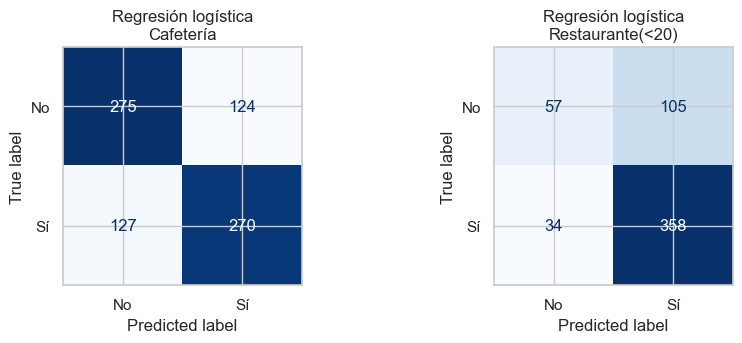

In [23]:
graficar_confusion('Regresión logística')

## Coeficientes del modelo

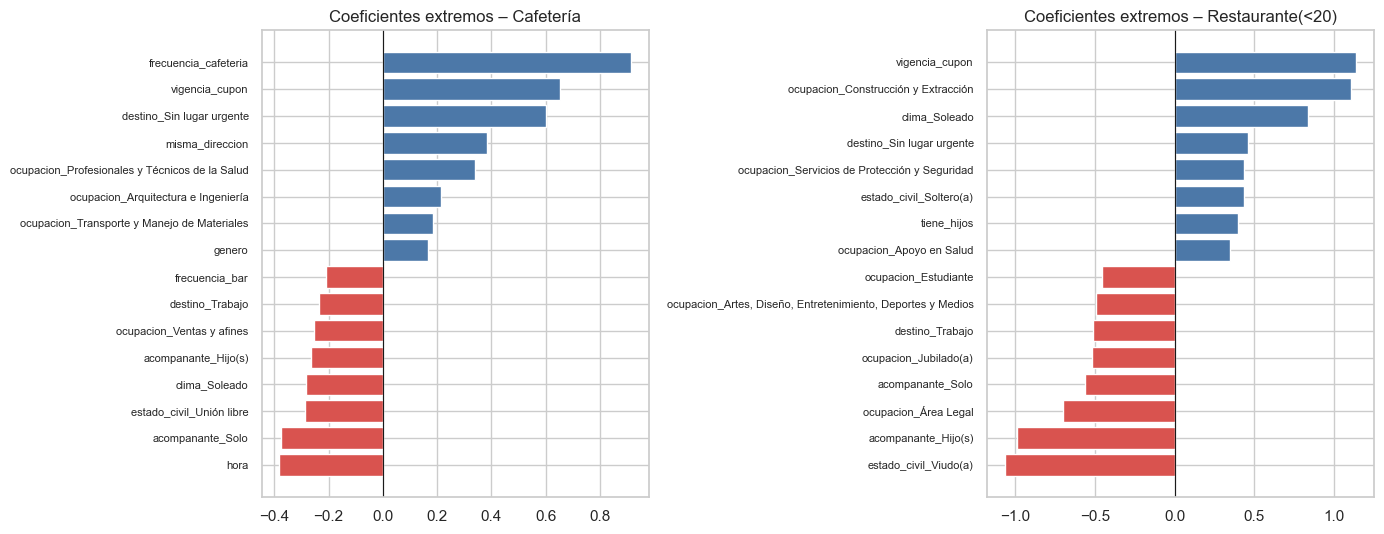

In [24]:
def tabla_coeficientes(cupon, n=8):
    mejor = resultados[('Regresión logística', cupon)]['modelo']
    nombres = mejor.named_steps['preprocesador'].get_feature_names_out()
    coef = pd.Series(mejor.named_steps['modelo'].coef_[0], index=nombres).sort_values()
    return coef

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, k in zip(axes, CUPONES):
    c = tabla_coeficientes(k)
    extremos = pd.concat([c.head(8), c.tail(8)])
    ax.barh(extremos.index, extremos.values, color=['#D9534F' if v < 0 else '#4C78A8' for v in extremos.values])
    ax.axvline(0, color='k', lw=.8); ax.set_title(f"Coeficientes extremos – {k}"); ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

## Análisis de los resultados de la regresión logística

**Hiperparámetros:** En Cafetería ganó `l2` + `liblinear` con `C = 0,05` (regularización fuerte), en Restaurante(<20), `l1` + `liblinear` con `C = 1` (regularización más suave), que dejó **8 de 50 coeficientes exactamente en 0**. El solver casi no importa: las ocho mejores configuraciones de cada cupón están a menos de 0,01 de F1-macro entre sí, porque para una misma penalización y un mismo `C` los solvers convergen a soluciones prácticamente iguales. Lo que sí pesa es la penalización y el valor de `C`.

**Cafetería:** F1-macro de 0,710 en validación cruzada y **0,685 en prueba**, con errores equilibrados entre clases (recall de `Sí` 0,680 y de `No` 0,689). La diferencia entre entrenamiento (0,717) y prueba (0,685) es pequeña: no hay sobreajuste, pero tampoco mucha capacidad; el modelo lineal se queda en un techo cercano al 68 % de aciertos.

**Restaurante(<20):** La exactitud de 0,749 parece aceptable, pero un modelo que respondiera siempre Sí acertaría el 70,8 % de las veces, así que apenas mejora esa referencia. El reporte lo confirma, el modelo detecta el 91 % de las aceptaciones (recall de `Sí` 0,913) pero **solo el 35 % de los rechazos** (recall de `No` 0,352), la clase minoritaria. El F1-macro en prueba es 0,644, lo que representa un comportamiento que favorece a la clase mayoritaria.

**Coeficientes:** 

- *Cafetería*: aumentan la probabilidad de aceptar la frecuencia con que el conductor visita cafeterías (+0,92), un cupón con vigencia de 1 día (+0,65), un destino Sin lugar urgente (+0,60) y que la cafetería esté en la misma dirección (+0,38). La disminuyen viajar solo o con hijos frente a ir con amigos, la hora (−0,38), el clima soleado frente al lluvioso y la unión libre frente al matrimonio.
- *Restaurante(<20)*: pesan sobre todo la vigencia de 1 día (+1,14), el clima soleado frente al lluvioso (+0,83) y el destino Sin lugar urgente frente a (+0,46); restan viajar con hijos (−0,99) o solo (−0,56) frente a ir con amigos, y que el destino sea el trabajo (−0,51). Los coeficientes de algunas ocupaciones y del estado civil Viudo(a) son grandes, pero corresponden a grupos muy pequeños (por ejemplo 130 viudos en todo el conjunto), así que se deben leer con cautela.

---
# 4 Árboles de decisión (un modelo por cupón)

**Pipeline.** `preparar` → `ColumnTransformer` → `DecisionTreeClassifier`. **Sin escalado**: las particiones dependen del orden de los valores, no de su magnitud. Los ordinales se codifican con su orden y las nominales con one-hot.

**Hiperparámetros explorados** (validación cruzada de 10 pliegues):

| Hiperparámetro | Valores | Efecto |
|---|---|---|
| `criterion` | `gini`, `entropy` | Medida de impureza para elegir la mejor pregunta. |
| `max_depth` | 3, 5, 7, 10, sin límite | Número máximo de niveles de preguntas. |
| `min_samples_leaf` | 1, 5, 10, 20 |Valores altos producen hojas más estables y árboles más simples. |

In [25]:
def pipeline_arbol():
    return Pipeline([
        ('preparar', preparador),
        ('preprocesador', construir_preprocesador(escalar=False, ohe_drop=None)),
        ('modelo', DecisionTreeClassifier(random_state=42)),
    ])

param_grid_arbol = {'modelo__criterion': ['gini', 'entropy'],
                    'modelo__max_depth': [3, 5, 7, 10, None],
                    'modelo__min_samples_leaf': [1, 5, 10, 20]}
print("Combinaciones por cupón:", np.prod([len(v) for v in param_grid_arbol.values()]), "x 10 pliegues")

for k in CUPONES:
    entrenar_y_evaluar('Árbol de decisión', k, pipeline_arbol(), param_grid_arbol, cv10)

Combinaciones por cupón: 40 x 10 pliegues


## Árbol de decisión – Cafetería

In [26]:
mostrar_evaluacion('Árbol de decisión', 'Cafetería')
resumen_busqueda(resultados[('Árbol de decisión', 'Cafetería')], ['modelo__criterion', 'modelo__max_depth', 'modelo__min_samples_leaf'])

### Árbol de decisión – Cafetería
Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1}
F1-macro medio en validación cruzada: 0.7127 (±0.0284) | tiempo de búsqueda: 4 s

Reporte de clasificación sobre TEST:
              precision    recall  f1-score   support

          No      0.691     0.672     0.681       399
          Sí      0.679     0.698     0.688       397

    accuracy                          0.685       796
   macro avg      0.685     0.685     0.685       796
weighted avg      0.685     0.685     0.685       796

Train vs Test:


,Exactitud,Precisión (Sí),Recall (Sí),F1 (Sí),Recall (No),F1-macro
Train,0.724,0.726,0.718,0.722,0.731,0.724
Test,0.685,0.679,0.698,0.688,0.672,0.685


,criterion,max_depth,min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,entropy,5,1,0.7127,0.0284,1
1,entropy,5,5,0.7108,0.0283,2
2,gini,5,20,0.7102,0.0282,3
3,gini,5,10,0.7089,0.0274,4
4,gini,5,5,0.7089,0.0294,5
5,gini,5,1,0.7089,0.0302,6
6,entropy,5,10,0.7086,0.0296,7
7,entropy,5,20,0.7084,0.0280,8


## Árbol de decisión – Restaurante(<20)

In [27]:
mostrar_evaluacion('Árbol de decisión', 'Restaurante(<20)')
resumen_busqueda(resultados[('Árbol de decisión', 'Restaurante(<20)')], ['modelo__criterion', 'modelo__max_depth', 'modelo__min_samples_leaf'])

### Árbol de decisión – Restaurante(<20)
Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5}
F1-macro medio en validación cruzada: 0.6623 (±0.0258) | tiempo de búsqueda: 3 s

Reporte de clasificación sobre TEST:
              precision    recall  f1-score   support

          No      0.610     0.395     0.479       162
          Sí      0.782     0.895     0.835       392

    accuracy                          0.749       554
   macro avg      0.696     0.645     0.657       554
weighted avg      0.731     0.749     0.731       554

Train vs Test:


,Exactitud,Precisión (Sí),Recall (Sí),F1 (Sí),Recall (No),F1-macro
Train,0.769,0.797,0.904,0.847,0.441,0.687
Test,0.749,0.782,0.895,0.835,0.395,0.657


,criterion,max_depth,min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,entropy,5,5,0.6623,0.0258,1
1,entropy,5,1,0.6615,0.0279,2
2,entropy,5,10,0.6554,0.0269,3
3,entropy,7,1,0.6521,0.0359,4
4,gini,5,1,0.6514,0.0284,5
5,gini,10,20,0.6513,0.0340,6
6,gini,None,20,0.6512,0.0339,7
7,gini,5,5,0.6493,0.0262,8


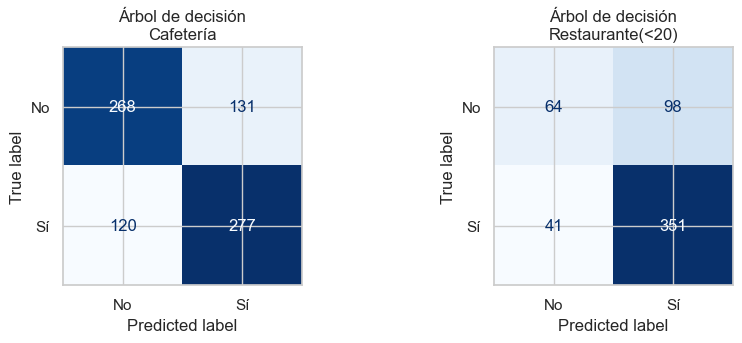

In [28]:
graficar_confusion('Árbol de decisión')

In [29]:
for k in CUPONES:
    r = pd.DataFrame(resultados[('Árbol de decisión', k)]['grid'].cv_results_)
    print(k)
    print("por max_depth:", r.groupby(r['param_modelo__max_depth'].fillna('sin límite').astype(str))['mean_test_score'].max().round(4).to_dict())
    print("por min_samples_leaf:", r.groupby(r['param_modelo__min_samples_leaf'].astype(str))['mean_test_score'].max().round(4).to_dict())

Cafetería
por max_depth: {'10': 0.6891, '3': 0.6751, '5': 0.7127, '7': 0.7076, 'sin límite': 0.6886}
por min_samples_leaf: {'1': 0.7127, '10': 0.7089, '20': 0.7102, '5': 0.7108}
Restaurante(<20)
por max_depth: {'10': 0.6513, '3': 0.6472, '5': 0.6623, '7': 0.6521, 'sin límite': 0.6512}
por min_samples_leaf: {'1': 0.6615, '10': 0.6554, '20': 0.6513, '5': 0.6623}


## Interpretación: importancia de variables y reglas

La importancia de un árbol resume cuánta impureza reduce cada variable a lo largo de todas sus particiones.

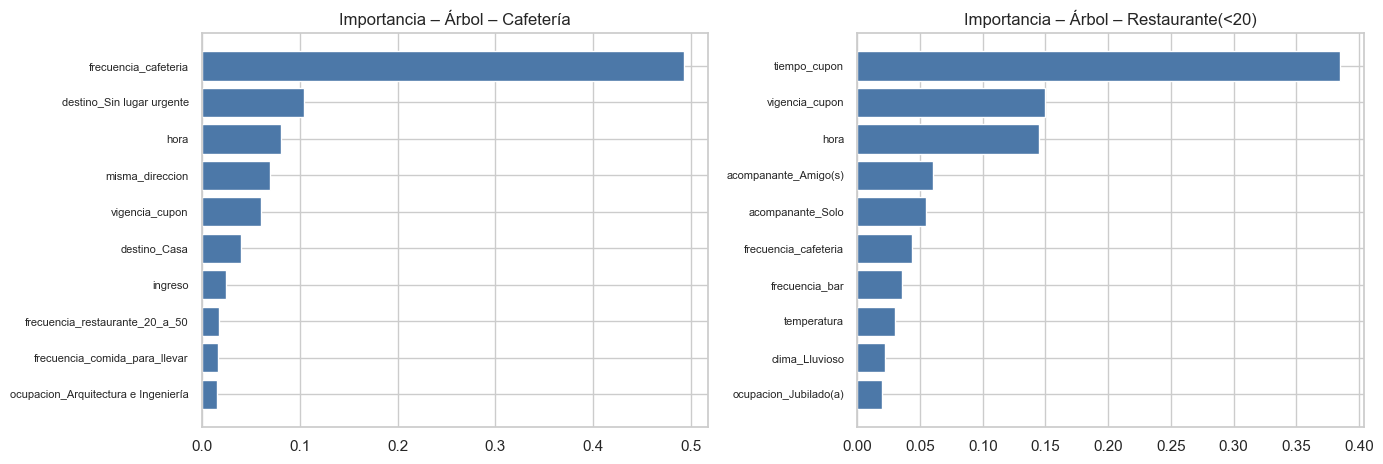

In [30]:
def importancias(nombre, cupon):
    mejor = resultados[(nombre, cupon)]['modelo']
    nombres = mejor.named_steps['preprocesador'].get_feature_names_out()
    return pd.Series(mejor.named_steps['modelo'].feature_importances_, index=nombres).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, k in zip(axes, CUPONES):
    imp = importancias('Árbol de decisión', k).head(10)[::-1]
    ax.barh(imp.index, imp.values, color='#4C78A8'); ax.set_title(f"Importancia – Árbol – {k}"); ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

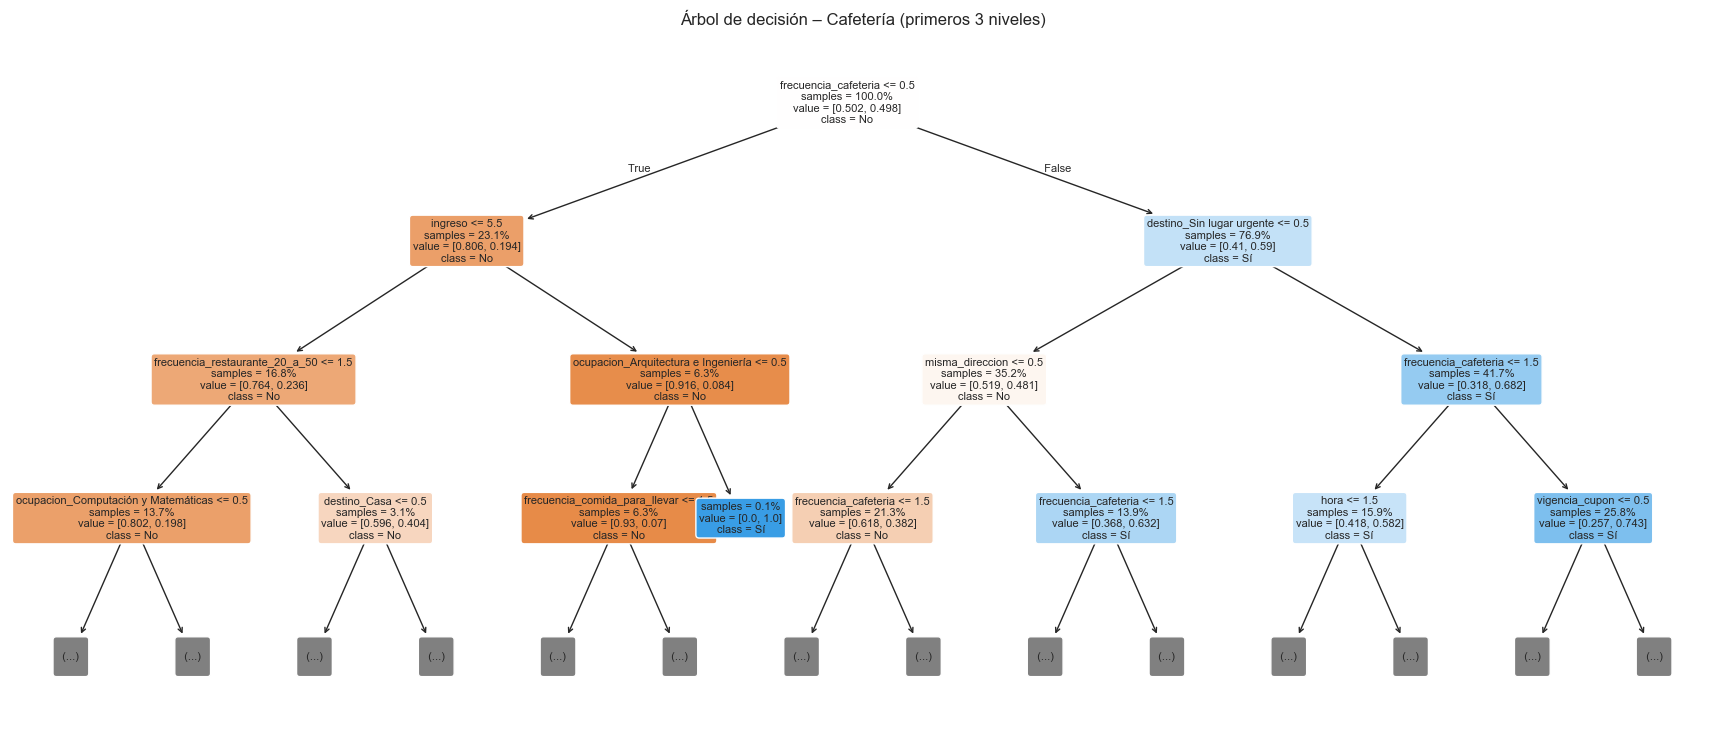

In [31]:
def graficar_arbol(cupon, profundidad=3):
    mejor = resultados[('Árbol de decisión', cupon)]['modelo']
    nombres = mejor.named_steps['preprocesador'].get_feature_names_out()
    plt.figure(figsize=(22, 9))
    plot_tree(mejor.named_steps['modelo'], feature_names=nombres, class_names=['No', 'Sí'], filled=True,
              rounded=True, fontsize=8, max_depth=profundidad, impurity=False, proportion=True)
    plt.title(f"Árbol de decisión – {cupon} (primeros {profundidad} niveles)"); plt.show()

graficar_arbol('Cafetería')

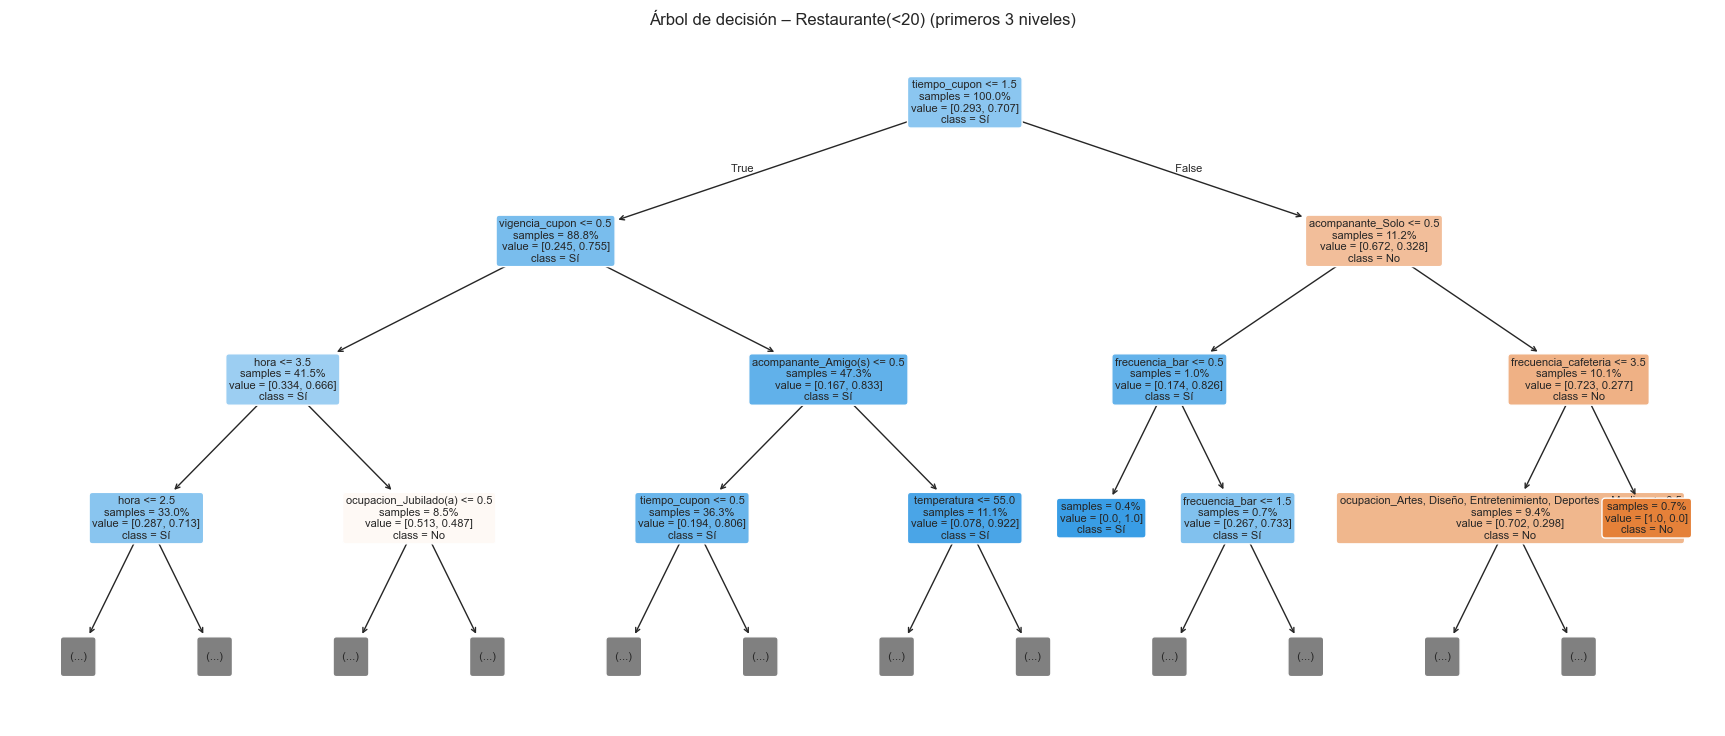

In [32]:
graficar_arbol('Restaurante(<20)')

## Análisis de los resultados del árbol de decisión

**Hiperparámetros.** En ambos cupones ganó `criterion='entropy'` con `max_depth=5`; la profundidad 5 es la mejor en ambos cupones: con 3 niveles el árbol se queda corto, y con 7 a 10 niveles o sin límite empieza a sobreajustar. `min_samples_leaf` casi no importa en esa profundidad (en Restaurante, 1 y 5 empatan en 0,6623).

**Desempeño.** El árbol queda prácticamente empatado con la regresión logística:

| | F1-macro CV | F1-macro test | Recall `Sí` | Recall `No` |
|---|---|---|---|---|
| Cafetería | 0,713 | 0,685 | 0,698 | 0,672 |
| Restaurante(<20) | 0,662 | 0,659 | 0,898 | 0,395 |

En Cafetería, las métricas de prueba son iguales a las de la regresión logística (0,685). En Restaurante(<20) el árbol mejora levemente (0,659 frente a 0,644) y detecta un poco más de rechazos (recall de No 0,395 frente a 0,352), pero sigue lejos de un desempeño balanceado entre clases.

**Qué aprendió (importancia y reglas).**

- *Cafetería*: la variable más importante por amplio margen es la frecuencia de visita a cafeterías (0,49 de la importancia total). El primer corte del árbol separa a quienes nunca van a cafeterías. Después pesan el destino Sin lugar urgente (0,10), la hora (0,08), que la cafetería esté en la misma dirección (0,07) y la vigencia (0,06). Esto es coherente con la exploración, quienes nunca visitan cafeterías aceptaban solo el 19 %.
- *Restaurante(<20)*: la variable dominante es la distancia al establecimiento (`tiempo_cupon`, 0,38), seguida por la vigencia (0,15) y la hora (0,14). Las reglas de los primeros niveles lo muestran: si el restaurante queda a más de 25 minutos (11% de los registros), solo el 33% acepta, y si además el conductor va solo el 72% rechaza, si queda a menos de 25 minutos, el cupón de 1 día se acepta en el 83% de los casos y el de 2 horas en el 67%.

---
# 5 Random Forest (un modelo por cupón)

**Pipeline.** `preparar` → `ColumnTransformer` → `RandomForestClassifier`, con el mismo preprocesamiento que el árbol (sin escalado).

**Hiperparámetros explorados** (validación cruzada de 5 pliegues):

| Hiperparámetro | Valores | Efecto |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Más árboles estabilizan el voto pero cuestan más. |
| `max_depth` | 6, 10, 15, sin límite | Profundidad máxima de cada árbol. |
| `min_samples_leaf` | 1, 3, 5 | Mínimo de registros por hoja. |

In [33]:
def pipeline_rf():
    return Pipeline([
        ('preparar', preparador),
        ('preprocesador', construir_preprocesador(escalar=False, ohe_drop=None)),
        ('modelo', RandomForestClassifier(random_state=42, n_jobs=1)),
    ])

param_grid_rf = {'modelo__n_estimators': [100, 200, 300],
                 'modelo__max_depth': [6, 10, 15, None],
                 'modelo__min_samples_leaf': [1, 3, 5]}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Combinaciones por cupón:", np.prod([len(v) for v in param_grid_rf.values()]), "x 5 pliegues")

for k in CUPONES:
    entrenar_y_evaluar('Random Forest', k, pipeline_rf(), param_grid_rf, cv5)

Combinaciones por cupón: 36 x 5 pliegues


## Random Forest – Cafetería

In [34]:
mostrar_evaluacion('Random Forest', 'Cafetería')
resumen_busqueda(resultados[('Random Forest', 'Cafetería')], ['modelo__n_estimators', 'modelo__max_depth', 'modelo__min_samples_leaf'])

### Random Forest – Cafetería
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
F1-macro medio en validación cruzada: 0.7630 (±0.0083) | tiempo de búsqueda: 17 s

Reporte de clasificación sobre TEST:
              precision    recall  f1-score   support

          No      0.778     0.772     0.775       399
          Sí      0.772     0.778     0.775       397

    accuracy                          0.775       796
   macro avg      0.775     0.775     0.775       796
weighted avg      0.775     0.775     0.775       796

Train vs Test:


,Exactitud,Precisión (Sí),Recall (Sí),F1 (Sí),Recall (No),F1-macro
Train,0.999,1.000,0.998,0.999,1.000,0.999
Test,0.775,0.772,0.778,0.775,0.772,0.775


,n_estimators,max_depth,min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,200,None,1,0.7630,0.0083,1
1,300,None,1,0.7618,0.0069,2
2,200,15,1,0.7602,0.0117,3
3,300,15,1,0.7598,0.0081,4
4,100,None,1,0.7558,0.0102,5
5,100,15,1,0.7498,0.0122,6
6,100,None,3,0.7458,0.0154,7
7,200,None,3,0.7451,0.0145,8


## Random Forest – Restaurante(<20)

In [35]:
mostrar_evaluacion('Random Forest', 'Restaurante(<20)')
resumen_busqueda(resultados[('Random Forest', 'Restaurante(<20)')], ['modelo__n_estimators', 'modelo__max_depth', 'modelo__min_samples_leaf'])

### Random Forest – Restaurante(<20)
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
F1-macro medio en validación cruzada: 0.7064 (±0.0137) | tiempo de búsqueda: 12 s

Reporte de clasificación sobre TEST:
              precision    recall  f1-score   support

          No      0.701     0.420     0.525       162
          Sí      0.794     0.926     0.855       392

    accuracy                          0.778       554
   macro avg      0.748     0.673     0.690       554
weighted avg      0.767     0.778     0.759       554

Train vs Test:


,Exactitud,Precisión (Sí),Recall (Sí),F1 (Sí),Recall (No),F1-macro
Train,0.999,0.999,0.999,0.999,0.998,0.999
Test,0.778,0.794,0.926,0.855,0.420,0.690


,n_estimators,max_depth,min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,200,None,1,0.7064,0.0137,1
1,300,None,1,0.7009,0.0155,2
2,300,15,1,0.6975,0.0144,3
3,100,None,1,0.6966,0.0102,4
4,200,15,1,0.6961,0.0089,5
5,100,15,1,0.6908,0.0101,6
6,300,10,1,0.6749,0.0057,7
7,300,None,3,0.6743,0.0142,8


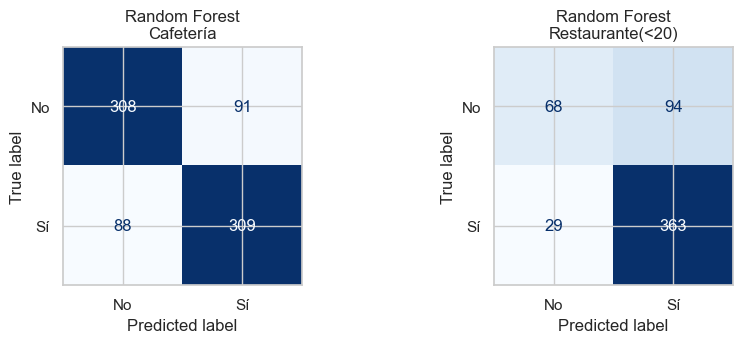

In [36]:
graficar_confusion('Random Forest')

## Importancia de variables

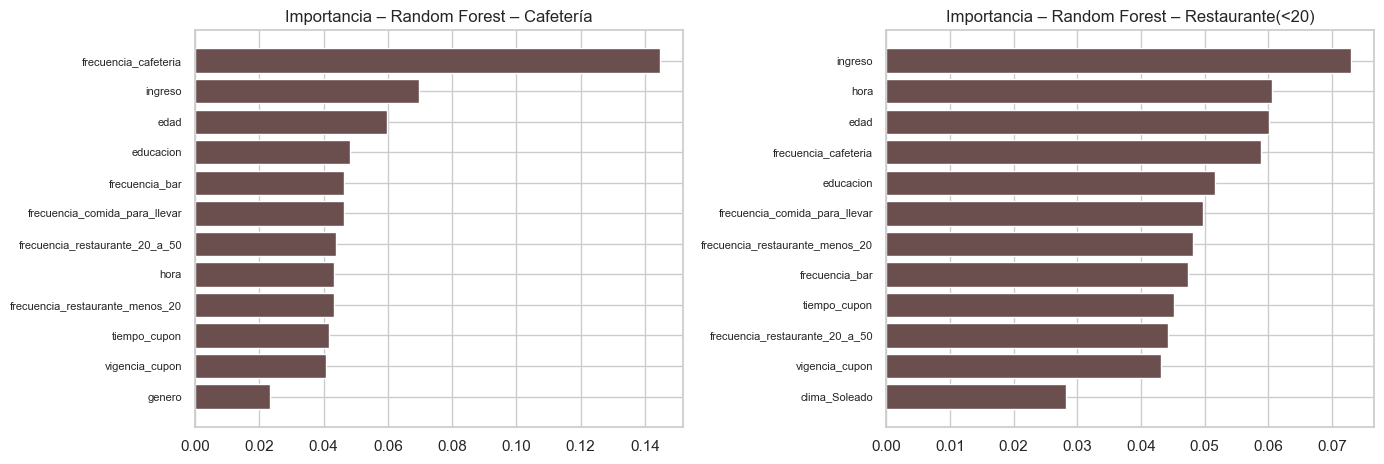

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, k in zip(axes, CUPONES):
    imp = importancias('Random Forest', k).head(12)[::-1]
    ax.barh(imp.index, imp.values, color='#6b4f4f'); ax.set_title(f"Importancia – Random Forest – {k}"); ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

## Análisis de los resultados del Random Forest

**Hiperparámetros.** Ganaron bosques de 200 árboles, con hojas de 1 registro y profundidad 15 (Cafetería) o sin límite (Restaurante(<20)). Las mejores configuraciones están en profundidad y hoja mínima (más restricción empeora claramente el resultado), y `min_samples_leaf=1` ya es el valor mínimo posible; ampliar `n_estimators` a 300 no mejoró (0,7586 y 0,7025 frente a 0,7602 y 0,7036 con 200), de modo que la búsqueda ya cubrió la zona útil.

**Desempeño.** Es el mejor de los tres algoritmos en ambos cupones en la prueba aleatoria:

| | F1-macro CV | F1-macro test | Recall `Sí` | Recall `No` | F1-macro train |
|---|---|---|---|---|---|
| Cafetería | 0,760 | 0,763 | 0,773 | 0,752 | 0,992 |
| Restaurante(<20) | 0,704 | 0,690 | 0,926 | 0,420 | 0,999 |

En Restaurante(<20) sigue el patrón de los otros modelos: recall de `Sí` alto, pero solo detecta el 42 % de los rechazos, un recall muy bajo para la clase mayoritaría, por lo que ya sería conveniente un balanceo de estilo `SMOTE`, el cual se va a realizar más adelante.

El desempeño de entrenamiento es casi perfecto (0,99) mientras que el de prueba es 0,69–0,76. El bosque memoriza los datos de entrenamiento, que las mejores configuraciones sean justamente las menos restringidas apunta a que el modelo se beneficia de **reconocer patrones muy específicos**. La importancia de las variables refuerza esto, pues en el bosque están muy repartidas y con peso de variables de tipo perfil (`ingreso`, `edad`, `educacion` y las frecuencias de consumo) cada una con 4–7% de la importancia, lo que crea una "huella dactilar" única de cada cliente en lugar de buscar la causa real del comportamiento. Mientras que los árboles de profundidad 5 se apoyaban en pocas variables (el hábito de visitar cafeterías en Cafetería. La distancia, la vigencia y la hora en Restaurante(<20)), priorizando la simplicidad y generalización a través de los datos.

---
# Resumen de los tres algoritmos sobre el conjunto de prueba

Tabla provisional con lo obtenido en las actividades 3–5. Las métricas de `Precisión`, `Recall` y `F1` son de la clase positiva `Sí`; `Recall (No)` mide la detección de rechazos (la clase minoritaria en Restaurante(<20)).

In [38]:
filas = []
for (alg, cup), r in resultados.items():
    filas.append({'Cupón': cup, 'Algoritmo': alg, **r['test'],
                  'F1-macro CV': r['grid'].best_score_,
                  'F1-macro train': r['train']['F1-macro']})
tabla_resumen = pd.DataFrame(filas).set_index(['Cupón', 'Algoritmo']).sort_index().round(3)
tabla_resumen

Exactitud  Precisión (Sí)  Recall (Sí)  F1 (Sí)  Recall (No)  F1-macro  F1-macro CV  F1-macro train
Cupón            Algoritmo                                                                                                               
Cafetería        Random Forest            0.775           0.772        0.778    0.775        0.772     0.775        0.763           0.999
                 Regresión logística      0.685           0.685        0.680    0.683        0.689     0.685        0.710           0.717
                 Árbol de decisión        0.685           0.679        0.698    0.688        0.672     0.685        0.713           0.724
Restaurante(<20) Random Forest            0.778           0.794        0.926    0.855        0.420     0.690        0.706           0.999
                 Regresión logística      0.749           0.773        0.913    0.837        0.352     0.644        0.649           0.658
                 Árbol de decisión        0.749           0.782        0.895    0.835        0.395     0.657        0.662           0.687

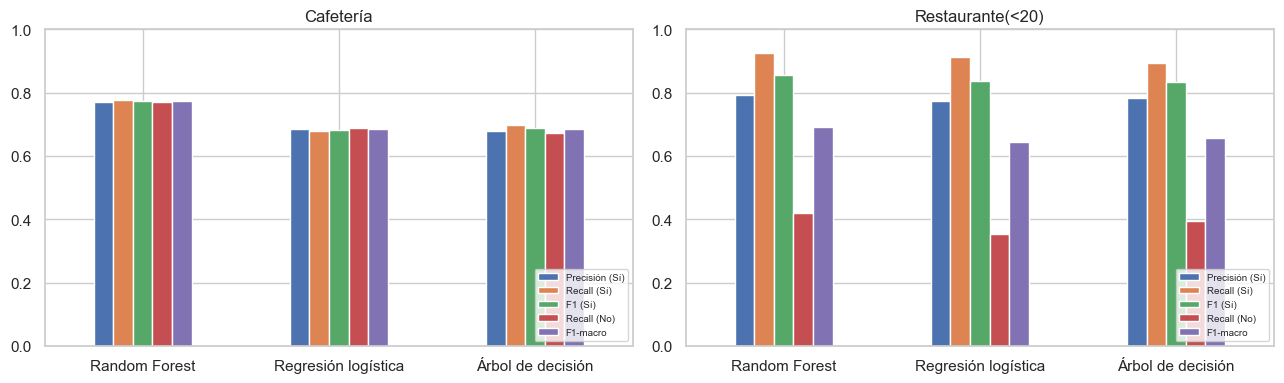

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, k in zip(axes, CUPONES):
    t = tabla_resumen.loc[k][['Precisión (Sí)', 'Recall (Sí)', 'F1 (Sí)', 'Recall (No)', 'F1-macro']]
    t.plot(kind='bar', ax=ax, rot=0); ax.set_ylim(0, 1); ax.set_title(k); ax.set_xlabel('')
    ax.legend(fontsize=7, loc='lower right')
plt.tight_layout(); plt.show()

# 6. Balanceo de clases, SMOTE

Como hemos visto en la clase del cupon de restaruante(<20) en todos los casos se llega a un resultado sesgado donde la clase mayoritaria es predicha con mayor exactitud, para minimizar este aspecto es necesario evaluar tecnicas de balanceo de clases como SMOTE

Podemos ver que la diferencia entre el numero de datos en cada clase en el caso de cupon de tipo restaurante(<20) es significativo

Cantidad de registros por cupón en el conjunto de datos:
cupon
Restaurante(<20)    2776
Name: count, dtype: int64
Cantidad de registros por aceptación de cupón en el conjunto de datos:
acepta_cupon
Sí    1962
No     814
Name: count, dtype: int64


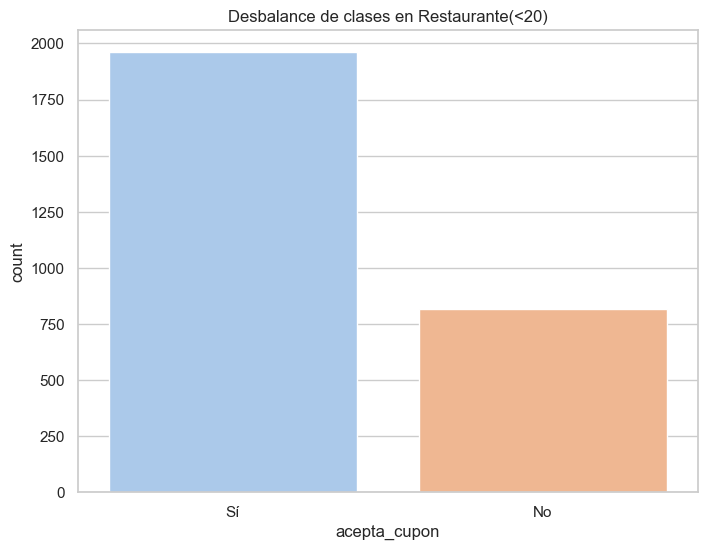

In [51]:
#grafiquemos el desbalance de clases en los datos originales para restaurante(<20)
plt.figure(figsize=(8, 6))
restaurante = data[data['cupon'] == 'Restaurante(<20)']
sns.countplot(x='acepta_cupon', data=restaurante, palette='pastel')
plt.title('Desbalance de clases en Restaurante(<20)')

print("Cantidad de registros por cupón en el conjunto de datos:")
print(restaurante['cupon'].value_counts())
print("Cantidad de registros por aceptación de cupón en el conjunto de datos:")
print(restaurante['acepta_cupon'].value_counts())

Podemos ver que la clase "Sí" tiene practicamente el doble de los registros que tiene la clase "No" y por esto vemos un comportamiento asimetrico cuando se evalua el desempeño, como hay mas evidencia de los datos de la clase mayoritaria el modelo tiene mas información para predecir los datos de esta clase y poca información para predecir los datos de la otra clase. 

Empecemos el proceso para aplicar SMOTE en cada uno de los algoritmos mostrados previamente.

In [102]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

datos_restaurante=datos_modelo['Restaurante(<20)']

#necesitamos balancear las clases para el cupón restaurante(<20) y lo haremos con SMOTE 
smote_rl_pipeline=ImbPipeline([
    ('preparar', preparador),
    ('preprocesador', construir_preprocesador(escalar=True, ohe_drop='first')),
    ('smote', SMOTE(random_state=42)),
    ('modelo', LogisticRegression(max_iter=2000, random_state=42))
])#todo el pipeline es igual al de regresion logistica pero se le agrega el paso de smote para balancear las clases

smote_rl_param_grid = GridSearchCV(smote_rl_pipeline, param_grid_rl, cv=cv10, scoring='f1_macro', n_jobs=-1, refit=True)

smote_rl_param_grid.fit(datos_restaurante['X_train'], datos_restaurante['y_train'])

print("Mejores hiperparámetros:", smote_rl_param_grid.best_params_)
print(f"F1-macro en validación cruzada: {smote_rl_param_grid.best_score_:.3f}")

Mejores hiperparámetros: {'modelo__C': 0.05, 'modelo__penalty': 'l2', 'modelo__solver': 'lbfgs'}
F1-macro en validación cruzada: 0.670


In [103]:
#veamos el desempeño de este nuevo modelo balanceado con SMOTE en el conjunto de train y de test
smote_rl_predictions = smote_rl_param_grid.predict(datos_restaurante['X_test'])
metricas_restaurante_smote_test = metricas(datos_restaurante['y_test'], smote_rl_predictions)
metricas_restaurante_smote_train=metricas(datos_restaurante['y_train'], smote_rl_param_grid.predict(datos_restaurante['X_train']))
#hagamos una tabla con las métricas de desempeño del modelo original y del modelo balanceado con SMOTE para el cupón restaurante(<20)
metricas_restaurante_original = resultados[('Regresión logística', 'Restaurante(<20)')]['test']
metricas_restaurante_original_train = resultados[('Regresión logística', 'Restaurante(<20)')]['train']
tabla_metricas_restaurante = pd.DataFrame({
    'Métricas': list(metricas_restaurante_original.keys()),
    'Original Train': list(metricas_restaurante_original_train.values()),
    'Original Test': list(metricas_restaurante_original.values()),
    'SMOTE Train': list(metricas_restaurante_smote_train.values()),
    'SMOTE Test': list(metricas_restaurante_smote_test.values())
}).set_index('Métricas').round(3)

#guardemos los resultados del smote para analizar despues
smote_rl_test=metricas_restaurante_smote_test.copy()
smote_rl_train=metricas_restaurante_smote_train.copy()

tabla_metricas_restaurante

,Original Train,Original Test,SMOTE Train,SMOTE Test
Métricas,,,,
Exactitud,0.762,0.749,0.717,0.708
Precisión (Sí),0.778,0.773,0.840,0.830
Recall (Sí),0.928,0.913,0.742,0.737
F1 (Sí),0.847,0.837,0.788,0.781
Recall (No),0.361,0.352,0.657,0.636
F1-macro,0.658,0.644,0.682,0.670


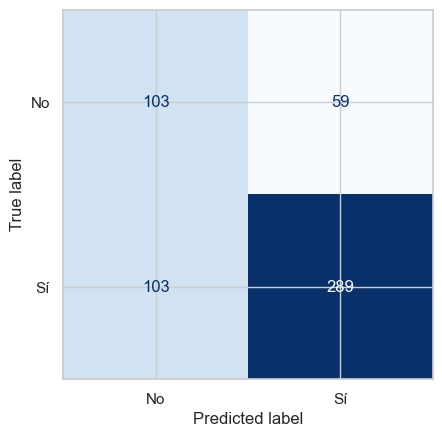

In [104]:
#grafiquemos la matriz de confusión del modelo balanceado con SMOTE para el cupón restaurante(<20)
ConfusionMatrixDisplay.from_predictions(datos_restaurante['y_test'], smote_rl_predictions,
                                        display_labels=['No', 'Sí'], cmap='Blues', colorbar=False)

Podemos ver que mejoró significativamente el recall(no), es decir el desempeño predictivo de la clase minoria. Esto sin sacrificar un valor significativo de desempeño general, por lo contrario hemos mejorado el desempeño general pues podemos ver valores de F1 mayores tanto en train como en test. Sin embargo es importante recalcar que de todas maneras el desempeño de la clase minoria sigue siendo menor a pesar de este cambio, es decir, mejoramos pero sigue habiendo un sesgo.

Hagamos lo mismo con el algoritmo de arboles de desicion

In [105]:
#ahora hagamos SMOTE para arboles de descion 
smote_arbol_pipeline=ImbPipeline([
    ('preparar', preparador),   
    ('preprocesador', construir_preprocesador(escalar=False, ohe_drop=None)),
    ('smote', SMOTE(random_state=42)),
    ('modelo', DecisionTreeClassifier(random_state=42))
])

smote_arbol_param_grid = GridSearchCV(smote_arbol_pipeline, param_grid_arbol, cv=cv10, scoring='f1_macro', n_jobs=-1, refit=True)
smote_arbol_param_grid.fit(datos_restaurante['X_train'], datos_restaurante['y_train'])

print("Mejores hiperparámetros:", smote_arbol_param_grid.best_params_)
print(f"F1-macro en validación cruzada: {smote_arbol_param_grid.best_score_:.3f}")

Mejores hiperparámetros: {'modelo__criterion': 'entropy', 'modelo__max_depth': 3, 'modelo__min_samples_leaf': 20}
F1-macro en validación cruzada: 0.668


In [106]:
#hagamos la matriz de confusión del modelo balanceado con SMOTE para el cupón restaurante(<20) usando arboles de decisión
smote_arbol_predictions = smote_arbol_param_grid.predict(datos_restaurante['X_test'])
metricas_restaurante_smote_test = metricas(datos_restaurante['y_test'], smote_arbol_predictions)
metricas_restaurante_smote_train=metricas(datos_restaurante['y_train'], smote_arbol_param_grid.predict(datos_restaurante['X_train']))
#hagamos una tabla con las métricas de desempeño del modelo original y del modelo balanceado con SMOTE para el cupón restaurante(<20)
metricas_restaurante_original = resultados[('Árbol de decisión', 'Restaurante(<20)')]['test']
metricas_restaurante_original_train = resultados[('Árbol de decisión', 'Restaurante(<20)')]['train']
tabla_metricas_restaurante = pd.DataFrame({
    'Métricas': list(metricas_restaurante_original.keys()),
    'Original Train': list(metricas_restaurante_original_train.values()),
    'Original Test': list(metricas_restaurante_original.values()),
    'SMOTE Train': list(metricas_restaurante_smote_train.values()),
    'SMOTE Test': list(metricas_restaurante_smote_test.values())
}).set_index('Métricas').round(3)

#guardemos los resultados del smote para analizar despues
smote_arbol_test=metricas_restaurante_smote_test.copy()
smote_arbol_train=metricas_restaurante_smote_train.copy()

tabla_metricas_restaurante

,Original Train,Original Test,SMOTE Train,SMOTE Test
Métricas,,,,
Exactitud,0.769,0.749,0.738,0.729
Precisión (Sí),0.797,0.782,0.795,0.789
Recall (Sí),0.904,0.895,0.849,0.842
F1 (Sí),0.847,0.835,0.821,0.815
Recall (No),0.441,0.395,0.469,0.457
F1-macro,0.687,0.657,0.666,0.656


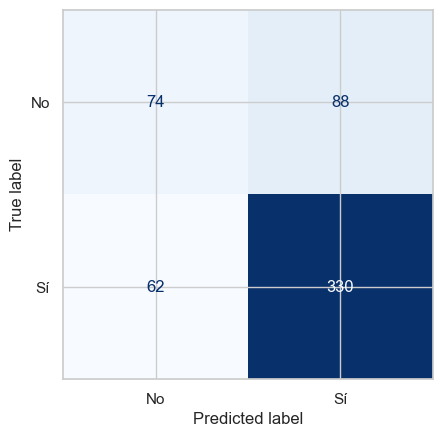

In [107]:
#grafiquemos la matriz anterior
ConfusionMatrixDisplay.from_predictions(datos_restaurante['y_test'], smote_arbol_predictions,
                                        display_labels=['No', 'Sí'], cmap='Blues', colorbar=False)

Podemos ver un comportamiento similar a la anterior instancia en el sentido que hay un progreso en la metrica de recall(no) y en el rendimiento general del modelo, sin embargo sigue habiendo un sesgo significativo y en general este ajuste fue menos efectivo que el SMOTE de la regresion logistica. El progreso fue mucho menor en este caso. De todas formas el analisis general se llevara a cabo al final. 

Por ultimo hagamos lo mismo con random forest

In [108]:
#ahora hagamos SMOTE con el modelo de Random Forest para el cupón restaurante(<20)
smote_rf_pipeline=ImbPipeline([
    ('preparar', preparador),
    ('preprocesador', construir_preprocesador(escalar=False, ohe_drop=None)),
    ('smote', SMOTE(random_state=42)),
    ('modelo', RandomForestClassifier(random_state=42, n_jobs=1))
])

smote_rf_param_grid = GridSearchCV(smote_rf_pipeline, param_grid_rf, cv=cv5, scoring='f1_macro', n_jobs=-1, refit=True)
smote_rf_param_grid.fit(datos_restaurante['X_train'], datos_restaurante['y_train'])

print("Mejores hiperparámetros:", smote_rf_param_grid.best_params_)
print(f"F1-macro en validación cruzada: {smote_rf_param_grid.best_score_:.3f}")

Mejores hiperparámetros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 300}
F1-macro en validación cruzada: 0.708


In [109]:
#veamos la matriz de confusión del modelo balanceado con SMOTE para el cupón restaurante(<20) de random forest
smote_rf_predictions = smote_rf_param_grid.predict(datos_restaurante['X_test'])
metricas_restaurante_smote_test = metricas(datos_restaurante['y_test'], smote_rf_predictions)
metricas_restaurante_smote_train=metricas(datos_restaurante['y_train'], smote_rf_param_grid.predict(datos_restaurante['X_train']))
#hagamos una tabla con las métricas de desempeño del modelo original y del modelo balanceado con SMOTE para el cupón restaurante(<20)
metricas_restaurante_original = resultados[('Random Forest', 'Restaurante(<20)')]['test']
metricas_restaurante_original_train = resultados[('Random Forest', 'Restaurante(<20)')]['train']
tabla_metricas_restaurante = pd.DataFrame({
    'Métricas': list(metricas_restaurante_original.keys()),
    'Original Train': list(metricas_restaurante_original_train.values()),
    'Original Test': list(metricas_restaurante_original.values()),
    'SMOTE Train': list(metricas_restaurante_smote_train.values()),
    'SMOTE Test': list(metricas_restaurante_smote_test.values())
}).set_index('Métricas').round(3)

#guardemos los resultados del smote para analizar despues
smote_rf_test=metricas_restaurante_smote_test.copy()
smote_rf_train=metricas_restaurante_smote_train.copy()

tabla_metricas_restaurante

,Original Train,Original Test,SMOTE Train,SMOTE Test
Métricas,,,,
Exactitud,0.999,0.778,0.999,0.771
Precisión (Sí),0.999,0.794,0.999,0.798
Recall (Sí),0.999,0.926,0.999,0.906
F1 (Sí),0.999,0.855,0.999,0.848
Recall (No),0.998,0.420,0.998,0.444
F1-macro,0.999,0.690,0.999,0.690


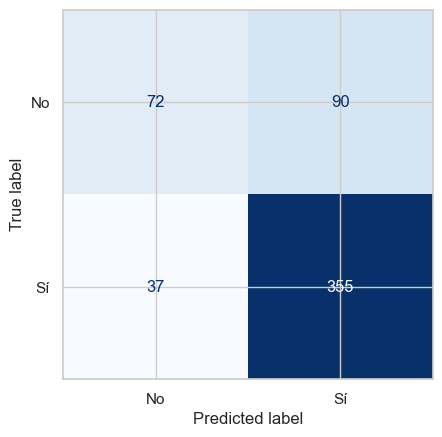

In [110]:
#graficamos la matriz de confusión del modelo balanceado con SMOTE para el cupón restaurante(<20) de random forest
ConfusionMatrixDisplay.from_predictions(datos_restaurante['y_test'], smote_rf_predictions,
                                        display_labels=['No', 'Sí'], cmap='Blues', colorbar=False)

Parecido al caso anterior podemos ver que hay un progreso pues la metrica de recall(no) aumenta pero sigue siendo mucho inferior y el progreso es poco. Podemos ver que de todas formas hay un incremento en el desempeño general pues el valor de f1 mejora tambien.

In [115]:
#hagamos una tabla final con todas las métricas de desempeño de los modelos originales y los modelos balanceados con SMOTE para el cupón restaurante(<20)
tabla=pd.DataFrame(
{
    'Métricas': list(metricas_restaurante_original.keys()),
    
    'Original Test RL': list(resultados[('Regresión logística', 'Restaurante(<20)')]['test'].values()),
    
    'Original Test Árbol': list(resultados[('Árbol de decisión', 'Restaurante(<20)')]['test'].values()),
    
    'Original Test RF': list(resultados[('Random Forest', 'Restaurante(<20)')]['test'].values()),
    
    'SMOTE RL Test': list(smote_rl_test.values()),
    
    'SMOTE Árbol Test': list(smote_arbol_test.values()),
    
    'SMOTE RF Test': list(smote_rf_test.values())
})
tabla

,Métricas,Original Test RL,Original Test Árbol,Original Test RF,SMOTE RL Test,SMOTE Árbol Test,SMOTE RF Test
0,Exactitud,0.749097,0.749097,0.777978,0.707581,0.729242,0.770758
1,Precisión (Sí),0.773218,0.781737,0.794311,0.830460,0.789474,0.797753
2,Recall (Sí),0.913265,0.895408,0.926020,0.737245,0.841837,0.905612
3,F1 (Sí),0.837427,0.834721,0.855124,0.781081,0.814815,0.848268
4,Recall (No),0.351852,0.395062,0.419753,0.635802,0.456790,0.444444
5,F1-macro,0.644010,0.657061,0.690110,0.670432,0.655730,0.689816


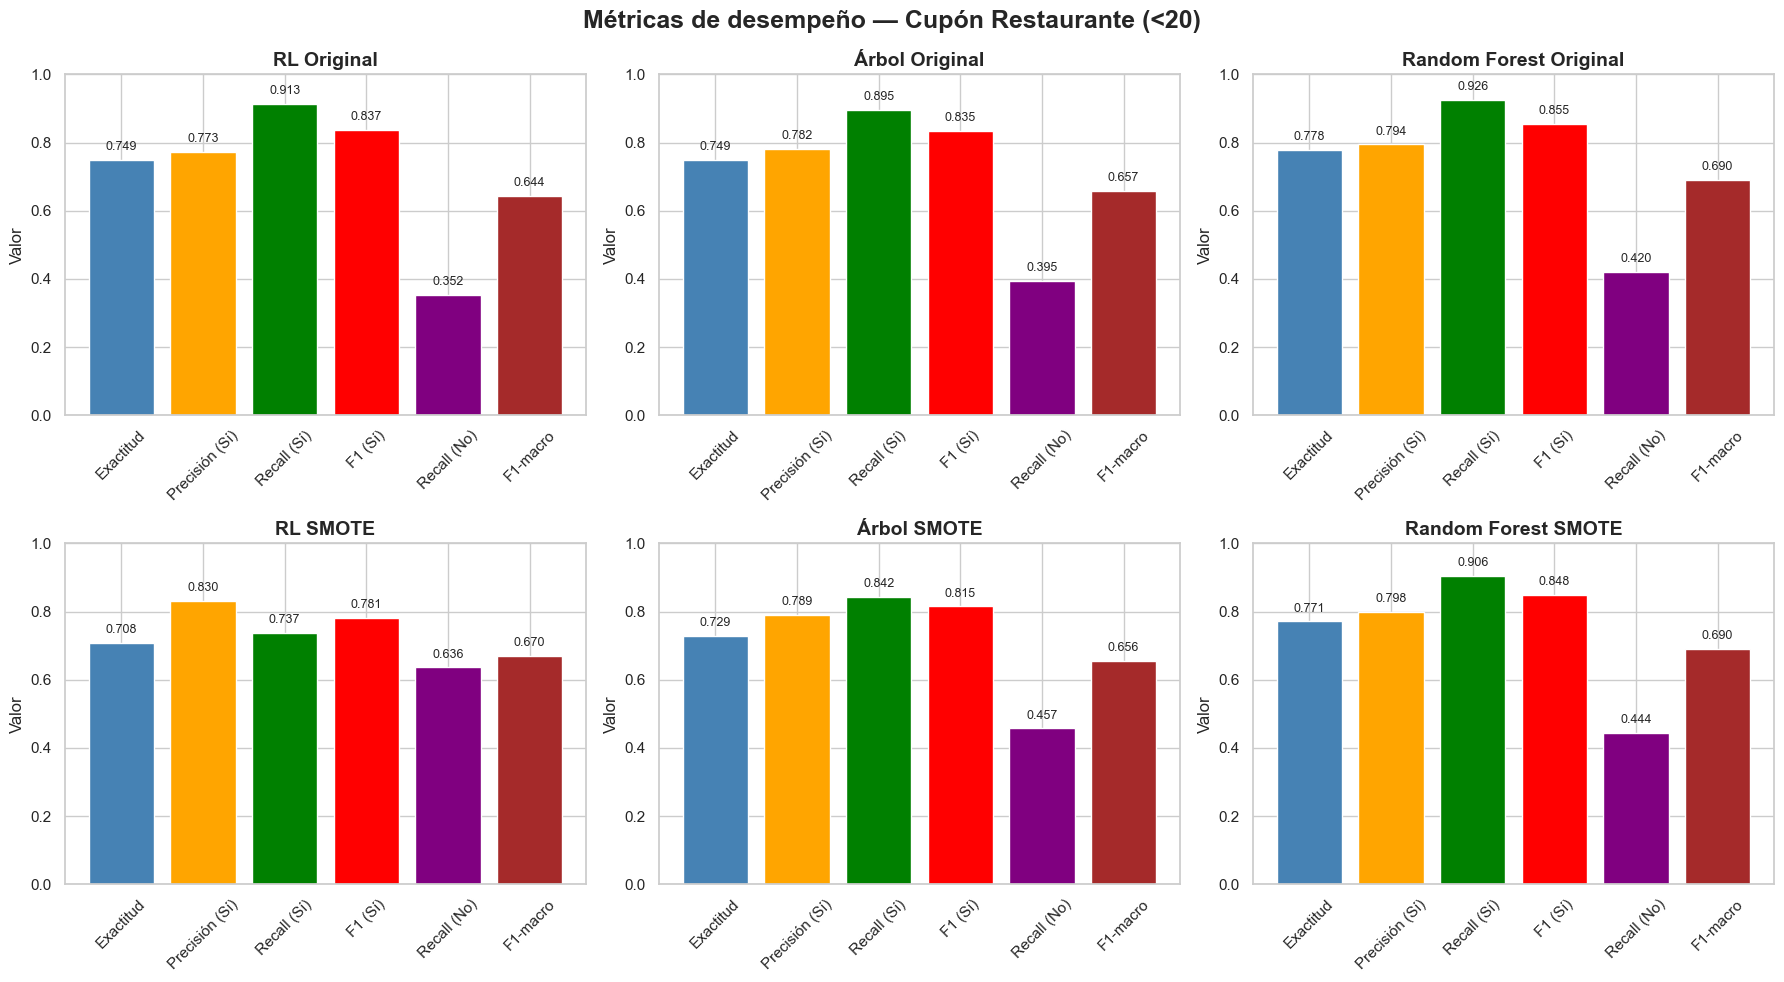

In [121]:
#grafiquemos cada variable de desempeño segun el algoritmo.


# Nombres de las métricas
metricas = [
    'Exactitud',
    'Precisión (Sí)',
    'Recall (Sí)',
    'F1 (Sí)',
    'Recall (No)',
    'F1-macro'
]

# Orden: primero todos los modelos originales y luego todos los SMOTE
modelos = {
    'RL Original': tabla['Original Test RL'].values,
    'Árbol Original': tabla['Original Test Árbol'].values,
    'Random Forest Original': tabla['Original Test RF'].values,
    
    'RL SMOTE': tabla['SMOTE RL Test'].values,
    'Árbol SMOTE': tabla['SMOTE Árbol Test'].values,
    'Random Forest SMOTE': tabla['SMOTE RF Test'].values
}

# Color fijo para cada métrica
colores = {
    'Exactitud': 'steelblue',
    'Precisión (Sí)': 'orange',
    'Recall (Sí)': 'green',
    'F1 (Sí)': 'red',
    'Recall (No)': 'purple',
    'F1-macro': 'brown'
}

# Crear los 6 gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (nombre, valores) in zip(axes.flatten(), modelos.items()):

    # Mismo color para la misma métrica en todos los gráficos
    colores_barras = [colores[metrica] for metrica in metricas]

    barras = ax.bar(
        metricas,
        valores,
        color=colores_barras
    )

    ax.set_title(nombre, fontsize=14, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_ylim(0, 1)

    # Rotar nombres de las métricas
    ax.tick_params(axis='x', rotation=45)

    # Mostrar valor encima de cada barra
    for barra, valor in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.02,
            f'{valor:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# Título general
plt.suptitle(
    'Métricas de desempeño — Cupón Restaurante (<20)',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


## Conclusiones de SMOTE

Como podemos ver en las graficas anteriores SMOTE cumple su proposito el cual es incrementar el valor de recall(no) es decir la predicción de la clase minoría. Podemos ver como siempre incrementa el valor de la barra purpura como evidencia. Vemos que este comportamiento es más evidente en el algoritmo de regresión logística donde también incrementó el valor de la metrica de F1-macro. En los demás casos no se vió un cambio significativo de F1-macro aunque si un aumento de recall(no). 

Podemos ver que a pesar de que se hizo un esfuerzo por igualar las clases de todas maneras el poder predicitivo hacia la clase minoritaria sigue siendo inferior en todos los casos, es decir no podemos decir que no existe un sesgo que beneficia a los datos pertenecientes a la clase mayoritaria. 

En canto a si se debería implementar SMOTE o no. SMOTE nos está reduciendo el sesgo hacia una clase lo cual siempre es benefisioso, además podemos ver que no empeora el desempeño general del modelo, es decir no hay un sacrificio de poder predictivo al intentar reducir el sesgo, y si hace al algoritmo más justo. Por ende se debería utilizar. En este caso el modelo más balanceado es el modelo que utiliza SMOTE de regresión logística, es decir la gráfica posicionada en la parte inferior izquierda. Podemos ver que tiene un desempeño ligeramente inferior al algorítmo de Random Forest pero tiene un sesgo mucho menor pues el recall(no) está mucho mas cerca al recall(si) por lo que se debería implementar este. 

Podemos ver que la necesidad de balancear las clases solo se descubrió en los cupones de tipo restaurante(<20) pues es donde se evidenciaban sesgos entre clases. Esto se debe a que el desbalance entre clases es minimo entre los cupones de tipo Cafeteria como podemos ver en la grafica más adelante. Cuando el desbalance es mayor, mayor es el sesgo y por ende mayor es la necesidad de implementar metodos como SMOTE que puedan balancear las clases.

Cantidad de registros por cupón en el conjunto de datos:
cupon
Cafetería    3986
Name: count, dtype: int64
Cantidad de registros por aceptación de cupón en el conjunto de datos:
acepta_cupon
No    1997
Sí    1989
Name: count, dtype: int64


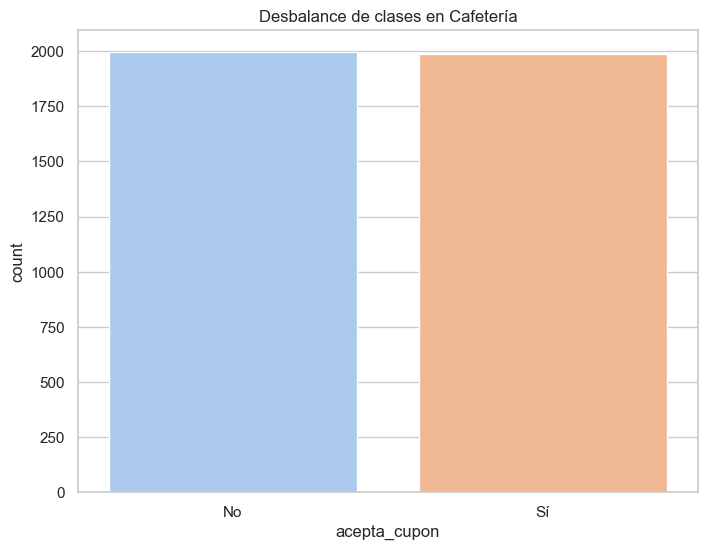

In [122]:
#grafiquemos el desbalance de clases en los datos originales para cafeteria
plt.figure(figsize=(8, 6))
cafeteria = data[data['cupon'] == 'Cafetería']
sns.countplot(x='acepta_cupon', data=cafeteria, palette='pastel')
plt.title('Desbalance de clases en Cafetería')

print("Cantidad de registros por cupón en el conjunto de datos:")
print(cafeteria['cupon'].value_counts())
print("Cantidad de registros por aceptación de cupón en el conjunto de datos:")
print(cafeteria['acepta_cupon'].value_counts())

## Conclusiones generales

Con ayuda de estos modelos se puede predecir si un cupon es propenso a ser aceptado o no. Con esta información se puede decidir cual cupon mostrar dependiendo de cual tiene mayor probabilidad de ser aceptado. El app correría el algoritmo predictor entre sus candidatos a cupones por mostrar y puede asi solo mostrar aquellos que sean predichos como aceptados. De esta manera desperdicia menos oportunidades en cupones que no se iban aceptar. 

El uso de variables como edad, género, estado civil e ingreso puede mejorar la personalización de ofertas(cupones), pero también introducir sesgos de representación, históricos, de selección y de medición. Estos riesgos adquieren mayor importancia cuando las predicciones se utilizan para tomar decisiones con consecuencias económicas. Mientras que en la asignación de cupones el impacto puede limitarse a quién recibe un beneficio, en precios dinámicos un modelo sesgado podría generar discriminación de precios, especialmente si utiliza variables sensibles o proxies de ellas. Por ello, cualquier aplicación de este tipo debería incorporar análisis de desempeño y equidad por grupo, además de evaluar cuidadosamente qué variables se utilizan y para qué finalidad. Si estos análisis no son llevados a cabo el algoritmo puede tratar distinto a personas dependiendo de su edad, raza o nivel económico, este no debería ser el caso, se deberia mantener una equidad evitando tomar desiciones con datos privilegiados por medio de proxies.

## Uso de herramientas de IA generativa

A lo largo del notebook se utilizó el autocompletado de copilot de github para facilitar la sintaxis del codigo, sin embargo no se utiliza para la creación autonoma. Para la redacción del parrafo de conclusión se adjunto una redacción inicial y fue corregida por ChatGPT para evitar gramatica erronea y puntos redundantes, este parrafo fue releido para verificar su calidad. ChatGPT también fue utilizado para facilitar las graficas. Se adjunto el codigo ya ejecutado de la tabla de resumen entre algoritmos con y sin SMOTE y se pidio que ayudara con un codigo para graficar esta información. 

### Predicciones
Por ultimo vamos a crear las predicciones a partir del modelo de regresion logistica con SMOTE pues es el mas justo y tiene muy buen desempeño para los cupones de Restaurante(<20) y con el modelo de random forest para los datos de cafeteria.


In [137]:
datos_prueba = pd.read_excel('data/Lab3_datos_Prueba.xlsx')

datos_prueba['prediccion_acepta_cupon'] = pd.Series(pd.NA, index=datos_prueba.index, dtype='object')
tipo_cupon = datos_prueba['cupon'].astype('string').str.strip()
X_prueba = datos_prueba.drop(columns=['acepta_cupon'], errors='ignore')

mascara_cafeteria = tipo_cupon == 'Cafetería'
if mascara_cafeteria.any():
    predicciones_cafeteria = resultados[('Random Forest', 'Cafetería')]['grid'].predict(
        X_prueba.loc[mascara_cafeteria]
    )
    datos_prueba.loc[mascara_cafeteria, 'prediccion_acepta_cupon'] = np.where(
        predicciones_cafeteria == 1, 'Sí', 'No'
    )

mascara_restaurante = tipo_cupon == 'Restaurante(<20)'
if mascara_restaurante.any():
    predicciones_restaurante = smote_rl_param_grid.predict(
        X_prueba.loc[mascara_restaurante]
    )
    datos_prueba.loc[mascara_restaurante, 'prediccion_acepta_cupon'] = np.where(
        predicciones_restaurante == 1, 'Sí', 'No'
    )

datos_prueba

,destino,acompanante,clima,temperatura,hora,cupon,vigencia_cupon,genero,edad,estado_civil,tiene_hijos,educacion,ocupacion,ingreso,vehiculo,frecuencia_bar,frecuencia_cafeteria,frecuencia_comida_para_llevar,frecuencia_restaurante_menos_20,frecuencia_restaurante_20_a_50,tiempo_cupon_mayor_5min,tiempo_cupon_mayor_15min,tiempo_cupon_mayor_25min,misma_direccion,direccion_opuesta,prediccion_acepta_cupon
0,Trabajo,Solo,Soleado,55,7:00 a.m.,Cafetería,2 horas,Femenino,50 o más,Divorciado(a),Sí,Posgrado (Maestría o Doctorado),Jubilado(a),$12.500 - $24.999,NaN,1 a 3,4 a 8,4 a 8,4 a 8,menos de 1,Sí,Sí,No,No,Sí,Sí
1,Sin lugar urgente,Amigo(s),Soleado,80,10:00 a.m.,Cafetería,2 horas,Femenino,31,Unión libre,No,Estudios universitarios sin título,Apoyo Administrativo y de Oficina,$75.000 - $87.499,NaN,menos de 1,1 a 3,más de 8,4 a 8,1 a 3,Sí,No,No,No,Sí,Sí
2,Sin lugar urgente,Amigo(s),Soleado,80,2:00 p.m.,Cafetería,2 horas,Femenino,31,Soltero(a),No,Pregrado,Transporte y Manejo de Materiales,$25.000 - $37.499,NaN,menos de 1,1 a 3,4 a 8,más de 8,menos de 1,Sí,Sí,No,No,Sí,Sí
3,Sin lugar urgente,Pareja,Soleado,80,10:00 a.m.,Cafetería,2 horas,Masculino,50 o más,Casado(a),Sí,Estudios universitarios sin título,Computación y Matemáticas,$50.000 - $62.499,NaN,nunca,más de 8,nunca,4 a 8,menos de 1,Sí,No,No,No,Sí,Sí
4,Sin lugar urgente,Amigo(s),Soleado,80,6:00 p.m.,Restaurante(<20),2 horas,Femenino,26,Soltero(a),No,Técnico/Tecnólogo,Desempleado(a),Menos de $12.500,NaN,1 a 3,menos de 1,4 a 8,menos de 1,4 a 8,Sí,Sí,No,No,Sí,No
5,Sin lugar urgente,Hijo(s),Soleado,80,2:00 p.m.,Restaurante(<20),1 día,Masculino,26,Casado(a),Sí,Pregrado,Computación y Matemáticas,$25.000 - $37.499,NaN,menos de 1,1 a 3,1 a 3,1 a 3,1 a 3,Sí,No,No,No,Sí,Sí
6,Sin lugar urgente,Solo,Soleado,80,2:00 p.m.,Restaurante(<20),2 horas,Femenino,36,Soltero(a),Sí,Posgrado (Maestría o Doctorado),"Educación, Formación y Bibliotecología",$37.500 - $49.999,NaN,menos de 1,nunca,4 a 8,1 a 3,menos de 1,Sí,Sí,No,No,Sí,No
7,Sin lugar urgente,Amigo(s),Soleado,80,6:00 p.m.,Restaurante(<20),1 día,Femenino,46,Casado(a),Sí,Estudios universitarios sin título,Cuidado Personal y Servicios,$37.500 - $49.999,NaN,nunca,menos de 1,menos de 1,1 a 3,menos de 1,Sí,Sí,No,No,Sí,Sí
8,Sin lugar urgente,Amigo(s),Soleado,80,2:00 p.m.,Restaurante(<20),2 horas,Femenino,31,Casado(a),No,Estudios universitarios sin título,Desempleado(a),$50.000 - $62.499,NaN,nunca,nunca,1 a 3,más de 8,1 a 3,Sí,Sí,No,No,Sí,Sí
9,Casa,Solo,Soleado,80,6:00 p.m.,Cafetería,1 día,Femenino,50 o más,Soltero(a),No,Bachillerato completo,Gerencia,$37.500 - $49.999,NaN,menos de 1,menos de 1,menos de 1,menos de 1,1 a 3,Sí,No,No,No,Sí,No
